## Pipeline de pré-processamento dos reviews do AirBnB, nas cidades de Lisboa e Rio de Janeiro, afim de pesquisa em Text mining pra uma tese de Mestrado em Ciência de dados.

- Universidade Européia
- Mestrado em Ciência de dados e Análise de Negócios
- Orientaora: Prof. Marina Cavique
- Autora: Gisele Maciel da Silva

### Fonte: https://insideairbnb.com/get-the-data/

Datasets:
- reviews.csv **(Rio de Janeiro)** snapshot: 26 September, 2025
- reviews.csv **(Lisboa)** snapshot: 21 September, 2025 

In [1]:
# ==========================================
# Importação das bibliotecas necessárias
# ==========================================
import pandas as pd
from langdetect import detect, LangDetectException # Detecta a língua do texto
import matplotlib.pyplot as plt
from collections import Counter
import re
import spacy
from spacy.lang.pt.stop_words import STOP_WORDS
import string
import seaborn as sns

In [2]:
# ==========================================
# mostra o texto completo em cada célula
# ==========================================
pd.set_option("display.max_colwidth", None)  

-------------------
## **Importação do dataset dos reviews da plataforma AirBnB:<br><br>Cidade: Rio de Janeiro.**

------------------

In [4]:
# ==========================================
# Carrega o dataset e exibe as primeiras linhas
# ==========================================
reviews_RJ = pd.read_csv('reviews_RJ.csv')
display(reviews_RJ)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,17878,64852,2010-07-15,135370,Tia,"This apartment is in a perfect location -- two blocks from the beach and two blocks from the Copacabana Palace (where anyone famous stays when they are in Rio), which means it´s a very safe neighborhood. The pictures very accurately depict what the apartment is like, so you´ll have no surprises. Max is very communicative and helpful. The four of us that stayed here would highly recommend it."
1,17878,76744,2010-08-11,10206,Mimi,we had a really great experience staying in Max's apartment. it was one block from copacabana beach with easy access to the local markets/shops. Max was very helpful and went out of his way to send a list of suggestions on things to do. I will refer friends to Max in the future if visiting Rio. \r<br/>\r<br/>Thanks for everything Max!
2,17878,137528,2010-11-12,230449,Orene,"In general very good and reasonable price.\r<br/>\r<br/>It is really great having local calls for free.It give an extra service to the apartment and tourists in Rio.\r<br/>\r<br/>Things that can be better:\r<br/>- towells in different colours, for differ the towels of each person (it is a bit silly...)\r<br/>- Air conditioning in the rooms\r<br/>- DVD device included to the TV\r<br/>- Some more kitchen things and better heating kitchen system (os fogos da cozinha electricos sao um poco lentos para cozinhar)\r<br/>\r<br/>All the rest was correct, we will recommend the apart for other people.\r<br/>\r<br/>"
3,17878,147594,2010-12-01,219338,David,The apt was nice and in a great location only a couple of blocks from the beach and shopping. Thanks for everything Max!
4,17878,152368,2010-12-12,266847,Armi,At Copacabana apartment is best the situation and BALCONY!\r<br/>Thanks Max (hope the door is fixed!)
...,...,...,...,...,...,...
1127711,1514437457708752048,1516714847844223728,2025-09-23,690266298,Marcia,Lugar agradável. Limpo .Voltaria a me hospedar novamente.
1127712,1511850455330924625,1518947692081911205,2025-09-26,379725718,Ibrahima,Merci pour ce séjour Marcela
1127713,1511911271242090004,1515297240177990631,2025-09-21,392354245,Larissa,"Apartamento impecável, tudo novo, cama muito confortável, e ja tinha tudo que precisavamos, cafeteira, pó de café, roupa de cama, toalha. E a localização é excelente, perto da praia e da lagoa, e de grandes marcas, do lado da loja da adidas"
1127714,1512484578495076797,1515281616208051997,2025-09-21,693171147,Ingryd,"Lugar tranquilo, aconchegante e muito bem localizado, praticamente ao lado do metrô. Da janela é possível ver o Arco da Lapa. Além disso, fica perto de pontos turísticos, farmácias e lanchonetes, com tudo por perto. Aproveitamos muito a estadia!"


In [5]:
# ==========================================
# Exibe informações sobre o dataset
# ==========================================
reviews_RJ.info()

<class 'pandas.DataFrame'>
RangeIndex: 1127716 entries, 0 to 1127715
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   listing_id     1127716 non-null  int64
 1   id             1127716 non-null  int64
 2   date           1127716 non-null  str  
 3   reviewer_id    1127716 non-null  int64
 4   reviewer_name  1127714 non-null  str  
 5   comments       1127680 non-null  str  
dtypes: int64(3), str(3)
memory usage: 51.6 MB


-------
## **Snapshot 26 September, 2025**
--------

In [6]:
# ==========================================
# data de início e data de fim do dataset
# ==========================================
reviews_RJ['date'] = pd.to_datetime(reviews_RJ['date'])

data_inicio = reviews_RJ['date'].min()
data_fim    = reviews_RJ['date'].max()

print("Data de início:", data_inicio)
print("Data de fim:",   data_fim)

Data de início: 2010-06-07 00:00:00
Data de fim: 2025-09-27 00:00:00


-------------------
## **Importação do dataset dos reviews da plataforma AirBnB:<br><br>Cidade: Lisboa**

------------------

In [7]:
# ==========================================
# Carrega o dataset e exibe as primeiras linhas
# ==========================================
reviews_Lisboa = pd.read_csv('reviews_Lisboa.csv')
display(reviews_Lisboa)

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,1113142,60014456,2016-01-18,35314589,Andre,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.
1,1113142,86635385,2016-07-17,36799194,Daniele,Perfect host. Everything was fine. I will certainly go there again when I'm back in Lisbon
2,1113142,94639801,2016-08-16,1826748,Sibtain,"All in all, it was a very good, modern apartment and the host was friendly & helpful (we had a small problem once and the response was swift). It was adequately furnished & equipped. Everything that was promised on the webpage was available. Weekly cleaning was certainly a plus. The location was central, just a few minutes drive to all shopping malls & even city center (supermarket & cafes nearby). The metro station is just a few minutes walk away. It was also not far from the airport. We always managed to find a parking for the car right at the building. We would like to thank again the host for everything. I would certainly recommend the apartment to anyone visiting Lisbon."
3,1113142,112991958,2016-11-09,5985047,Nathan,Lovely apartment and frictionless stay. Booked the apartment for a work trip and at one point had to cancel and rebook which was not a problem. <br/>Lovely clean apartment and just what we required. The area has some nice coffee shops and restaurants and is very near the airport. <br/>
4,1113142,215013241,2017-11-27,154490966,Agenor,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.
...,...,...,...,...,...,...
1763336,1510413467473919870,1513052314242279756,2025-09-18,331829016,Theo,"Exactly as described, very close to the airport, about 40 mins from city center and the transport options are easy. Thiago is very kind and responsive."
1763337,1511494579746678997,1514442899745124973,2025-09-20,347744471,Silvia,"Siamo stati lì qualche giorno per il nostro viaggio di nozze, la casa è molto ampia con spazi ben definiti e comoda anche per la vicinanza all aereoporto e ad altre attività per esplorare Lisbona"
1763338,1511647298326136757,1513779000021044117,2025-09-19,331758965,Lucas,"Fantastic location right in the centre of town and pink street, with loads to see and plenty of great restaurants nearby. Lara was super responsive and incredibly welcoming — she made everything so easy. I’d happily recommend staying here and would book again."
1763339,1511647298326136757,1514457798488715662,2025-09-20,35122608,Nuno,"Beautiful, spotless studio with a lift in the heart of Lisbon. The area is lively and full of restaurants and bars, but once the windows are closed it’s wonderfully quiet — perfect mix of energy and comfort."


In [8]:
# ==========================================
# Exibe informações sobre o dataset
# ==========================================
reviews_Lisboa.info()

<class 'pandas.DataFrame'>
RangeIndex: 1763341 entries, 0 to 1763340
Data columns (total 6 columns):
 #   Column         Dtype
---  ------         -----
 0   listing_id     int64
 1   id             int64
 2   date           str  
 3   reviewer_id    int64
 4   reviewer_name  str  
 5   comments       str  
dtypes: int64(3), str(3)
memory usage: 80.7 MB


---------
## **Snapshot 21 September, 2025**
---------

In [8]:
# ==========================================
# data de início e data de fim do dataset
# ==========================================
reviews_Lisboa['date'] = pd.to_datetime(reviews_Lisboa['date'])

data_inicio = reviews_Lisboa['date'].min()
data_fim    = reviews_Lisboa['date'].max()

print("Data de início:", data_inicio)
print("Data de fim:",   data_fim)

Data de início: 2010-07-24 00:00:00
Data de fim: 2025-10-07 00:00:00


-------
## Os datasets precisam ser concatenados, sendo gerado somente um dataset, para isso, será preciso ser criado uma nova coluna para diferencia-los por cidade.
--------

In [9]:
# ==========================================
# Adicionando a coluna "cidade" para identificar a origem dos dados
# ==========================================
reviews_RJ["cidade"] = "Rio de Janeiro"
reviews_Lisboa["cidade"] = "Lisboa"

In [10]:
# ==========================================
# Exibe as primeiras linhas do dataset do Rio de Janeiro
# ==========================================
reviews_RJ.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade
0,17878,64852,2010-07-15,135370,Tia,"This apartment is in a perfect location -- two blocks from the beach and two blocks from the Copacabana Palace (where anyone famous stays when they are in Rio), which means it´s a very safe neighborhood. The pictures very accurately depict what the apartment is like, so you´ll have no surprises. Max is very communicative and helpful. The four of us that stayed here would highly recommend it.",Rio de Janeiro
1,17878,76744,2010-08-11,10206,Mimi,we had a really great experience staying in Max's apartment. it was one block from copacabana beach with easy access to the local markets/shops. Max was very helpful and went out of his way to send a list of suggestions on things to do. I will refer friends to Max in the future if visiting Rio. \r<br/>\r<br/>Thanks for everything Max!,Rio de Janeiro
2,17878,137528,2010-11-12,230449,Orene,"In general very good and reasonable price.\r<br/>\r<br/>It is really great having local calls for free.It give an extra service to the apartment and tourists in Rio.\r<br/>\r<br/>Things that can be better:\r<br/>- towells in different colours, for differ the towels of each person (it is a bit silly...)\r<br/>- Air conditioning in the rooms\r<br/>- DVD device included to the TV\r<br/>- Some more kitchen things and better heating kitchen system (os fogos da cozinha electricos sao um poco lentos para cozinhar)\r<br/>\r<br/>All the rest was correct, we will recommend the apart for other people.\r<br/>\r<br/>",Rio de Janeiro
3,17878,147594,2010-12-01,219338,David,The apt was nice and in a great location only a couple of blocks from the beach and shopping. Thanks for everything Max!,Rio de Janeiro
4,17878,152368,2010-12-12,266847,Armi,At Copacabana apartment is best the situation and BALCONY!\r<br/>Thanks Max (hope the door is fixed!),Rio de Janeiro


In [11]:
# ==========================================
# Exibe as primeiras linhas do dataset de Lisboa
# ==========================================
reviews_Lisboa.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade
0,1113142,60014456,2016-01-18,35314589,Andre,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.,Lisboa
1,1113142,86635385,2016-07-17,36799194,Daniele,Perfect host. Everything was fine. I will certainly go there again when I'm back in Lisbon,Lisboa
2,1113142,94639801,2016-08-16,1826748,Sibtain,"All in all, it was a very good, modern apartment and the host was friendly & helpful (we had a small problem once and the response was swift). It was adequately furnished & equipped. Everything that was promised on the webpage was available. Weekly cleaning was certainly a plus. The location was central, just a few minutes drive to all shopping malls & even city center (supermarket & cafes nearby). The metro station is just a few minutes walk away. It was also not far from the airport. We always managed to find a parking for the car right at the building. We would like to thank again the host for everything. I would certainly recommend the apartment to anyone visiting Lisbon.",Lisboa
3,1113142,112991958,2016-11-09,5985047,Nathan,Lovely apartment and frictionless stay. Booked the apartment for a work trip and at one point had to cancel and rebook which was not a problem. <br/>Lovely clean apartment and just what we required. The area has some nice coffee shops and restaurants and is very near the airport. <br/>,Lisboa
4,1113142,215013241,2017-11-27,154490966,Agenor,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.,Lisboa


------
### Os reviews estão em vários idiomas, então criar uma função para detetar o idioma de cada review e criar uma nova coluna para identificar qual o idioma, se não for identificado pela função, retornará "UNKNOWN". 

-----------
# **Reviews da cidade do Rio de Janeiro**

------------
## **Detetar idiomas**

----------


In [33]:
# ==========================================
# Função para detectar o idioma do texto usando a biblioteca langdetect
# ==========================================
def detectar_idioma(texto):
    try:
        texto = str(texto).strip()
        if len(texto) < 3:
            return "UNKNOWN"
        return detect(texto)   # ex: 'pt', 'en', 'es'
    except LangDetectException:
        return "UNKNOWN"

reviews_RJ["lang"] = reviews_RJ["comments"].apply(detectar_idioma)

In [ ]:
reviews_RJ

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang
0,17878,64852,2010-07-15,135370,Tia,"This apartment is in a perfect location -- two blocks from the beach and two blocks from the Copacabana Palace (where anyone famous stays when they are in Rio), which means it´s a very safe neighborhood. The pictures very accurately depict what the apartment is like, so you´ll have no surprises. Max is very communicative and helpful. The four of us that stayed here would highly recommend it.",Rio de Janeiro,en
1,17878,76744,2010-08-11,10206,Mimi,we had a really great experience staying in Max's apartment. it was one block from copacabana beach with easy access to the local markets/shops. Max was very helpful and went out of his way to send a list of suggestions on things to do. I will refer friends to Max in the future if visiting Rio. \r<br/>\r<br/>Thanks for everything Max!,Rio de Janeiro,en
2,17878,137528,2010-11-12,230449,Orene,"In general very good and reasonable price.\r<br/>\r<br/>It is really great having local calls for free.It give an extra service to the apartment and tourists in Rio.\r<br/>\r<br/>Things that can be better:\r<br/>- towells in different colours, for differ the towels of each person (it is a bit silly...)\r<br/>- Air conditioning in the rooms\r<br/>- DVD device included to the TV\r<br/>- Some more kitchen things and better heating kitchen system (os fogos da cozinha electricos sao um poco lentos para cozinhar)\r<br/>\r<br/>All the rest was correct, we will recommend the apart for other people.\r<br/>\r<br/>",Rio de Janeiro,en
3,17878,147594,2010-12-01,219338,David,The apt was nice and in a great location only a couple of blocks from the beach and shopping. Thanks for everything Max!,Rio de Janeiro,en
4,17878,152368,2010-12-12,266847,Armi,At Copacabana apartment is best the situation and BALCONY!\r<br/>Thanks Max (hope the door is fixed!),Rio de Janeiro,en
...,...,...,...,...,...,...,...,...
1127711,1514437457708752048,1516714847844223728,2025-09-23,690266298,Marcia,Lugar agradável. Limpo .Voltaria a me hospedar novamente.,Rio de Janeiro,pt
1127712,1511850455330924625,1518947692081911205,2025-09-26,379725718,Ibrahima,Merci pour ce séjour Marcela,Rio de Janeiro,fr
1127713,1511911271242090004,1515297240177990631,2025-09-21,392354245,Larissa,"Apartamento impecável, tudo novo, cama muito confortável, e ja tinha tudo que precisavamos, cafeteira, pó de café, roupa de cama, toalha. E a localização é excelente, perto da praia e da lagoa, e de grandes marcas, do lado da loja da adidas",Rio de Janeiro,pt
1127714,1512484578495076797,1515281616208051997,2025-09-21,693171147,Ingryd,"Lugar tranquilo, aconchegante e muito bem localizado, praticamente ao lado do metrô. Da janela é possível ver o Arco da Lapa. Além disso, fica perto de pontos turísticos, farmácias e lanchonetes, com tudo por perto. Aproveitamos muito a estadia!",Rio de Janeiro,pt


In [35]:
# ==========================================
# Salva o dataset atualizado com a nova coluna "lang"
# ==========================================
reviews_RJ.to_csv("reviews_RJ_lang.csv", index=False)

-----
## **Contar a Frequencia de cada idioma**
-------

In [12]:
# ==========================================
# Abrindo o dataset do Rio de Janeiro salvo com a coluna "lang"
# ==========================================
reviews_RJ_lang = pd.read_csv("reviews_RJ_lang.csv")
reviews_RJ_lang.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang
0,17878,64852,2010-07-15,135370,Tia,"This apartment is in a perfect location -- two blocks from the beach and two blocks from the Copacabana Palace (where anyone famous stays when they are in Rio), which means it´s a very safe neighborhood. The pictures very accurately depict what the apartment is like, so you´ll have no surprises. Max is very communicative and helpful. The four of us that stayed here would highly recommend it.",Rio de Janeiro,en
1,17878,76744,2010-08-11,10206,Mimi,we had a really great experience staying in Max's apartment. it was one block from copacabana beach with easy access to the local markets/shops. Max was very helpful and went out of his way to send a list of suggestions on things to do. I will refer friends to Max in the future if visiting Rio. \r<br/>\r<br/>Thanks for everything Max!,Rio de Janeiro,en
2,17878,137528,2010-11-12,230449,Orene,"In general very good and reasonable price.\r<br/>\r<br/>It is really great having local calls for free.It give an extra service to the apartment and tourists in Rio.\r<br/>\r<br/>Things that can be better:\r<br/>- towells in different colours, for differ the towels of each person (it is a bit silly...)\r<br/>- Air conditioning in the rooms\r<br/>- DVD device included to the TV\r<br/>- Some more kitchen things and better heating kitchen system (os fogos da cozinha electricos sao um poco lentos para cozinhar)\r<br/>\r<br/>All the rest was correct, we will recommend the apart for other people.\r<br/>\r<br/>",Rio de Janeiro,en
3,17878,147594,2010-12-01,219338,David,The apt was nice and in a great location only a couple of blocks from the beach and shopping. Thanks for everything Max!,Rio de Janeiro,en
4,17878,152368,2010-12-12,266847,Armi,At Copacabana apartment is best the situation and BALCONY!\r<br/>Thanks Max (hope the door is fixed!),Rio de Janeiro,en


In [14]:
# ==========================================
# Exibe a frequência dos idiomas detectados
# ==========================================
freq_lang_RJ = reviews_RJ_lang["lang"].value_counts()
freq_lang_RJ

lang
pt         721089
en         179334
es         160078
fr          25651
de           8906
it           7623
ro           4707
UNKNOWN      4438
lt           2337
nl           1844
ca           1621
ru           1137
he            913
sk            705
so            650
tl            607
hr            495
sv            483
hu            483
da            451
zh-cn         447
af            423
no            404
ko            340
fi            316
id            295
pl            268
tr            227
cy            220
ja            208
sw            184
cs            177
sl            174
lv            136
et            134
vi             55
el             46
ar             31
uk             24
zh-tw          23
bg             16
sq             13
mk              3
Name: count, dtype: int64

------
## **Grafico de Barras para mostrar o top 5 da frequencia de cada idioma**
--------

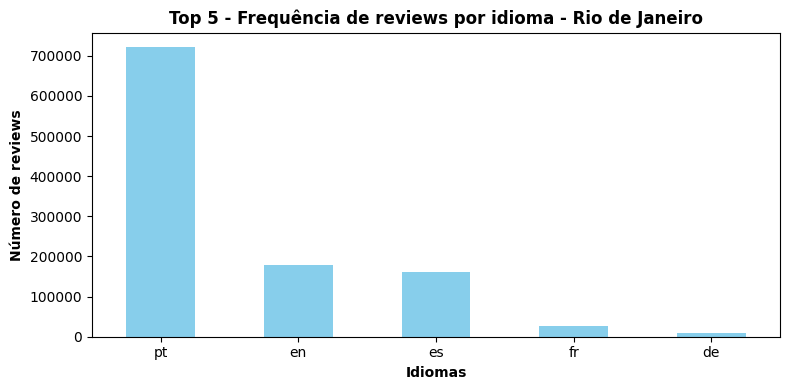

Gráfico de barras para a frequência de idiomas Top 5 - Rio de Janeiro salvo como 'frequencia_idiomas_RJ.png'


<Figure size 640x480 with 0 Axes>

In [17]:
# ==========================================
# Gráfico de barras para a frequência de idiomas Top 5 - Rio de Janeiro
# ==========================================
plt.figure(figsize=(8, 4))

freq_lang_RJ.sort_values(ascending=False).head(5).plot(
    kind="bar", color="skyblue"
)

plt.xlabel("Idiomas", fontweight="bold")
plt.ylabel("Número de reviews", fontweight="bold")
plt.title("Top 5 - Frequência de reviews por idioma - Rio de Janeiro", fontsize=12, fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# Salva o grafico de barras para a frequência de idiomas Top 5 - Rio de Janeiro
# ==========================================
plt.savefig("frequencia_idiomas_RJ.png", dpi=300, bbox_inches="tight")
print("Gráfico de barras para a frequência de idiomas Top 5 - Rio de Janeiro salvo como 'frequencia_idiomas_RJ.png'")

------------
## **Reviews da cidade do Rio de Janeiro em PORTUGUES:**
------------

In [16]:
# ==========================================
# Filtra apenas as reviews em português
# ==========================================
reviews_RJ_pt = reviews_RJ_lang[reviews_RJ_lang["lang"] == "pt"].copy()

reviews_RJ_pt.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang
17,17878,597736,2011-10-04,989464,Jose Mauro,"Muito Melhor do que ir para um hotel. Apt com excelente localização( 1 quarteirão da praia), muito organizado e limpo. O proprietário sempre muito solicito para resolver qualquer problema. O Apt também tem um terraço maravilhoso. Esta é a melhor maneira de conhecer o RIO\r<br/>\r<br/>",Rio de Janeiro,pt
18,17878,620065,2011-10-11,1157847,Gabriel,"Muito bom o apartamento, a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto.",Rio de Janeiro,pt
34,248756,3425364,2013-01-28,4175433,Nelson,"O apartamento é maravilhoso, novo, bem decorado, muito bem equipado, possui tudo que se precisa. A localização é perfeita próxima a tudo, tanto de Copacabana quanto Ipanema. Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã. Toda minha família se sentiu acolhida e bem a vontade. Um abraço pra todos e com certeza recomendo este apartamento, como também me hospedarei novamente nele de volta ao Rio.",Rio de Janeiro,pt
36,248756,3620482,2013-02-26,4781492,Rui Nuno,"Excelente apartamento, com ótimas condições e muito bem localizado. Fica perto de tudo - praias, supermercado, padaria, metro e festa - e está muito bem decorado. Recomendamos claramente. Fomos fantasticamente recebidos e deram-nos boas dicas para visitar a cidade. Só ficámos duas noites, mas valeu bem.\r<br/>Obrigado por tudo e sejam felizes.",Rio de Janeiro,pt
40,248756,4272123,2013-04-23,4893381,Isabella,"Dias Maravilhosos! Ap. muito bem decorado e com ótima localização, tudo como combinado. Recomendo!",Rio de Janeiro,pt


In [16]:
# ==========================================
# Salvar o DataFrame filtrado em um arquivo pickle
# ==========================================
reviews_RJ_pt.to_pickle("reviews_RJ_pt.pkl")

-----
## **Pré-processamento**
---------

In [177]:
# ==========================================
# Abrir o dataset do Rio de Janeiro na versão filtrada para português
# ==========================================
df_RJ_pt = pd.read_pickle("reviews_RJ_pt.pkl")
df_RJ_pt.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang
17,17878,597736,2011-10-04,989464,Jose Mauro,"Muito Melhor do que ir para um hotel. Apt com excelente localização( 1 quarteirão da praia), muito organizado e limpo. O proprietário sempre muito solicito para resolver qualquer problema. O Apt também tem um terraço maravilhoso. Esta é a melhor maneira de conhecer o RIO\r<br/>\r<br/>",Rio de Janeiro,pt
18,17878,620065,2011-10-11,1157847,Gabriel,"Muito bom o apartamento, a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto.",Rio de Janeiro,pt
34,248756,3425364,2013-01-28,4175433,Nelson,"O apartamento é maravilhoso, novo, bem decorado, muito bem equipado, possui tudo que se precisa. A localização é perfeita próxima a tudo, tanto de Copacabana quanto Ipanema. Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã. Toda minha família se sentiu acolhida e bem a vontade. Um abraço pra todos e com certeza recomendo este apartamento, como também me hospedarei novamente nele de volta ao Rio.",Rio de Janeiro,pt
36,248756,3620482,2013-02-26,4781492,Rui Nuno,"Excelente apartamento, com ótimas condições e muito bem localizado. Fica perto de tudo - praias, supermercado, padaria, metro e festa - e está muito bem decorado. Recomendamos claramente. Fomos fantasticamente recebidos e deram-nos boas dicas para visitar a cidade. Só ficámos duas noites, mas valeu bem.\r<br/>Obrigado por tudo e sejam felizes.",Rio de Janeiro,pt
40,248756,4272123,2013-04-23,4893381,Isabella,"Dias Maravilhosos! Ap. muito bem decorado e com ótima localização, tudo como combinado. Recomendo!",Rio de Janeiro,pt


In [178]:
# ==========================================
# Verificar valores nulos
# ==========================================
print("Valores nulos por coluna:\n", df_RJ_pt.isnull().sum())

Valores nulos por coluna:
 listing_id       0
id               0
date             0
reviewer_id      0
reviewer_name    2
comments         0
cidade           0
lang             0
dtype: int64


In [179]:
# ==========================================
# Conta quantas linhas duplicadas existem no dataset filtrado para português
# ==========================================
print("Número de linhas duplicadas:", df_RJ_pt.duplicated().sum())

Número de linhas duplicadas: 0


In [180]:
# ==========================================
# Descrição estatistica do número de caracteres e palavras
# ==========================================
df_RJ_pt['char_count'] = df_RJ_pt['comments'].astype(str).apply(len)
df_RJ_pt['word_count'] = df_RJ_pt['comments'].astype(str).apply(lambda x: len(x.split()))
print(df_RJ_pt[['char_count', 'word_count']].describe())

          char_count     word_count
count  721089.000000  721089.000000
mean      214.173153      33.906808
std       191.224703      31.763061
min         3.000000       1.000000
25%        87.000000      13.000000
50%       161.000000      25.000000
75%       279.000000      44.000000
max      6523.000000     995.000000


In [181]:
df_RJ_pt.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang,char_count,word_count
17,17878,597736,2011-10-04,989464,Jose Mauro,"Muito Melhor do que ir para um hotel. Apt com excelente localização( 1 quarteirão da praia), muito organizado e limpo. O proprietário sempre muito solicito para resolver qualquer problema. O Apt também tem um terraço maravilhoso. Esta é a melhor maneira de conhecer o RIO\r<br/>\r<br/>",Rio de Janeiro,pt,283,47
18,17878,620065,2011-10-11,1157847,Gabriel,"Muito bom o apartamento, a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto.",Rio de Janeiro,pt,111,22
34,248756,3425364,2013-01-28,4175433,Nelson,"O apartamento é maravilhoso, novo, bem decorado, muito bem equipado, possui tudo que se precisa. A localização é perfeita próxima a tudo, tanto de Copacabana quanto Ipanema. Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã. Toda minha família se sentiu acolhida e bem a vontade. Um abraço pra todos e com certeza recomendo este apartamento, como também me hospedarei novamente nele de volta ao Rio.",Rio de Janeiro,pt,454,75
36,248756,3620482,2013-02-26,4781492,Rui Nuno,"Excelente apartamento, com ótimas condições e muito bem localizado. Fica perto de tudo - praias, supermercado, padaria, metro e festa - e está muito bem decorado. Recomendamos claramente. Fomos fantasticamente recebidos e deram-nos boas dicas para visitar a cidade. Só ficámos duas noites, mas valeu bem.\r<br/>Obrigado por tudo e sejam felizes.",Rio de Janeiro,pt,345,52
40,248756,4272123,2013-04-23,4893381,Isabella,"Dias Maravilhosos! Ap. muito bem decorado e com ótima localização, tudo como combinado. Recomendo!",Rio de Janeiro,pt,98,14


-----
## **Função única de limpeza textual para remover quebras de linhas, tags HTML, números, pontuação e caracteres especiais que atrapalham a semântica do texto.**
------

In [ ]:
# ==========================================
# Função única de limpeza textual
# ==========================================
nlp = spacy.load("pt_core_news_lg")


def limpar_texto(texto):
    texto = str(texto)

    # Remover quebras de linha e tags HTML simples
    texto = texto.replace("\\r<br/>", " ")
    texto = texto.replace("<br/>", " ")
    texto = texto.replace("br", " ")

    # Remover tags HTML genéricas
    texto = re.sub(r"<.*?>", " ", texto)

    # Remover números
    texto = re.sub(r"\d+", " ", texto)

    # Remover pontuação e caracteres especiais, mantendo letras acentuadas e espaços
    texto = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", texto)

    # Remover espaços múltiplos
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()


In [182]:
df_RJ_pt["texto_limpo"] = df_RJ_pt["comments"].apply(limpar_texto)
df_RJ_pt.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang,char_count,word_count,texto_limpo
17,17878,597736,2011-10-04,989464,Jose Mauro,"Muito Melhor do que ir para um hotel. Apt com excelente localização( 1 quarteirão da praia), muito organizado e limpo. O proprietário sempre muito solicito para resolver qualquer problema. O Apt também tem um terraço maravilhoso. Esta é a melhor maneira de conhecer o RIO\r<br/>\r<br/>",Rio de Janeiro,pt,283,47,Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO
18,17878,620065,2011-10-11,1157847,Gabriel,"Muito bom o apartamento, a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto.",Rio de Janeiro,pt,111,22,Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto
34,248756,3425364,2013-01-28,4175433,Nelson,"O apartamento é maravilhoso, novo, bem decorado, muito bem equipado, possui tudo que se precisa. A localização é perfeita próxima a tudo, tanto de Copacabana quanto Ipanema. Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã. Toda minha família se sentiu acolhida e bem a vontade. Um abraço pra todos e com certeza recomendo este apartamento, como também me hospedarei novamente nele de volta ao Rio.",Rio de Janeiro,pt,454,75,O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio
36,248756,3620482,2013-02-26,4781492,Rui Nuno,"Excelente apartamento, com ótimas condições e muito bem localizado. Fica perto de tudo - praias, supermercado, padaria, metro e festa - e está muito bem decorado. Recomendamos claramente. Fomos fantasticamente recebidos e deram-nos boas dicas para visitar a cidade. Só ficámos duas noites, mas valeu bem.\r<br/>Obrigado por tudo e sejam felizes.",Rio de Janeiro,pt,345,52,Excelente apartamento com ótimas condições e muito bem localizado Fica perto de tudo praias supermercado padaria metro e festa e está muito bem decorado Recomendamos claramente Fomos fantasticamente recebidos e deram nos boas dicas para visitar a cidade Só ficámos duas noites mas valeu bem O igado por tudo e sejam felizes
40,248756,4272123,2013-04-23,4893381,Isabella,"Dias Maravilhosos! Ap. muito bem decorado e com ótima localização, tudo como combinado. Recomendo!",Rio de Janeiro,pt,98,14,Dias Maravilhosos Ap muito bem decorado e com ótima localização tudo como combinado Recomendo


--------
# **Anonimatizar nomes próprios de anfitriões:**

- Detectar nomes próprios
- Criar uma lista de nomes próprios
- Anonimizar esses nomes
- Substituídos por "host_anfitriao"

-------

In [ ]:
# ==========================================
# carrega o modelo de linguagem portuguesa para spaCy e guarda na variável nlp
# ==========================================
nlp = spacy.load("pt_core_news_lg")

# ==========================================
# Função de extração de nomes próprios, já com texto pré‑limpo
# ==========================================
def extrair_nomes_proprios(texto):
    texto_limpo = limpar_texto(texto)       # Primeiro limpa o texto
    doc = nlp(texto_limpo)                  # Extrai apenas entidades com label PER (pessoas)
    
    return [ent.text for ent in doc.ents if ent.label_ == "PER"]


In [183]:
# ==========================================
# Aplica sobre a coluna texto_limpo
# ==========================================
df_RJ_pt["nomes_proprios"] = df_RJ_pt["texto_limpo"].apply(extrair_nomes_proprios)

In [184]:
# ==========================================
# transforma cada elemento de lista numa linha individual, gerando uma série plana de todos os nomes
# ==========================================
todos_nomes_RJ = df_RJ_pt["nomes_proprios"].explode().dropna()

# ==========================================
# Contar frequência de cada nome
# ==========================================
contagem_nomes_RJ = Counter(todos_nomes_RJ.dropna())

# ==========================================
# Obter os 100 nomes mais frequentes e suas contagens
# ==========================================
top_100_RJ = contagem_nomes_RJ.most_common(100)

# ==========================================
# Somar a repetição desses 100 primeiros nomes
# ==========================================
soma_top_100_RJ = sum(contagem for nome, contagem in top_100_RJ)

print("100 nomes mais frequentes:")
for nome, contagem in top_100_RJ:
    print(f"{nome}: {contagem}")

print(f"\nSoma de repetições dos 100 primeiros nomes mais frequentes: {soma_top_100_RJ}")

100 nomes mais frequentes:
Ótima: 14554
Amei: 9008
Anfitrião: 8947
Anfitriã: 6196
Ana: 4599
Adorei: 3979
Apto: 3963
Agradeço: 3911
Maria: 3096
Rafael: 3086
Gostei: 3018
Daniel: 2941
Carlos: 2865
Parabéns: 2758
Pedro: 2693
Bruno: 2660
Eduardo: 2391
Fernanda: 2367
Luiz: 2185
Rodrigo: 2171
Fernando: 2154
Único: 2077
Felipe: 2029
Luciana: 2027
Márcia: 1977
Alexandre: 1964
Adriana: 1845
Claudia: 1787
Fui: 1632
Simone: 1628
Achei: 1603
Anfitriões: 1554
Patrícia: 1518
Me: 1509
Casa: 1483
Guilherme: 1451
Renata: 1372
Fabiana: 1367
Bruna: 1351
Renato: 1342
João: 1322
Mônica: 1319
Agradecemos: 1285
Fábio: 1285
Leonardo: 1270
Andrea: 1222
Flávia: 1169
Quero: 1142
Ricardo: 1142
Cris: 1132
Tatiana: 1124
Gustavo: 1097
Anderson: 1082
Igor: 1081
Paulo: 1045
Silvia: 1044
Nossa: 1042
Denise: 1040
Sem: 1029
Beatriz: 1029
Deus: 1010
José: 1010
Márcio: 996
Sérgio: 976
Paula: 966
Cristo: 955
Yuri: 951
Juliana: 948
Vanessa: 922
Carol: 917
Roberto: 901
Diego: 899
Carla: 895
Daniela: 893
Cláudio: 876
Ronaldo: 

In [185]:
# ==========================================
# Lista de todos os nomes próprios do dataset, sem repetições
# ==========================================
nomes_unicos_RJ = (
    df_RJ_pt["nomes_proprios"]
    .explode()
    .dropna()
    .drop_duplicates()
)

# ==========================================
# Converter para set para usar em substituição
# ==========================================
nomes_alvo_RJ = set(nomes_unicos_RJ)

print(f"Nomes próprios distintos encontrados: {len(nomes_alvo_RJ)}")


Nomes próprios distintos encontrados: 32240


In [192]:
# ==========================================
# Remover manualmente todas as palavras que não são nomes próprios, que a funcão não conseguiu detetar
# ==========================================
palavras_a_excluir_RJ = {"Ótima", "ótimas", "Ótimas", "Óptima", "Ótimo", "Óptimo", "Ótimos", "ótimos", "otimo", "otima", "otimos", "otimas", "Anfitrião", "anfitriao", "anfitrião", "anfitriã", "Anfitriã", "anfitria", "Gostei", "gostei", "Gostamos", "Agradeço", "Agradecemos", "Super", "Precisa", "agradeço", "Agradecer", "Grato", "Amei", "amei", "Parabéns", "Parabens", "parabens", "Anfitriões", "Anfitrões", "Adorei", "adorei", "Achei", "Único", "Casa", "casa", "Checkin", "checkin", "chekout", "Chekout", "Muitíssimo", "muitíssimo", "Apto limpo", "Atenciosa", "atenciosa", "Simpático", "Gentil", "Simpática", "Difícil", "Volto", "Fantástico", "Perfeita", "Boas", "Satisfeito", "Magnífico", "Casa linda", "Adoraria", "PERFEITA", "Senti-me", "Silêncio", "Supriu", "Gracias", "Recebeu-nos", "Vc", "Idêntico", "msgs", "Solicitei", "Quero", "Queria", "cómodo", "Cómodo", "Fui", "Apto", "Ambiente", "Vamos", "Voltaria", "Voltaríamos", "Confortável", "Grata", "Perfeito", "Incrível", "Melhor", "Apartamento", "Cama confortável", "Roupas", "Quarto", "Quartos", "Inclusive", "Limpeza", "Desejo", "Impecável", "Lugar", "Confesso", "Condiz", "Queríamos", "Amplo", "Janela", "Portas", "Cama", "Nossa", "Sem", "Minha", "Igual", "linda", "ctza", "msg", "AP", "Linda", "Meu", "Mto", "Zero", "Pude", "Banheiro", "Condomínio", "Percebe", "Correspondeu", "Nada", "Únicos", "Seguro", "Parecia", "Permitiu", "Estrelas", "Dormimos", "Acho", "Pequeno", "Grande", "Disseram", "Fabulous", "Gentileza", "Simplesmente", "Estela", "Comuniquei", "Proprietária", "confortável Voltaria", "Prático", "Espero", "Fico", "Adorámos", "Poderia", "mem"}
todos_nomes_RJ = df_RJ_pt["nomes_proprios"].explode().dropna()
nomes_serie_RJ = todos_nomes_RJ[~todos_nomes_RJ.isin(palavras_a_excluir_RJ)]

contagem_nomes_RJ = Counter(nomes_serie_RJ)
top_500_RJ = contagem_nomes_RJ.most_common(500)

print("500 nomes próprios mais frequentes (sem 'Ótima' e termos genéricos):")
for nome, frequencia in top_500_RJ:
    print(f"{nome}: {frequencia}")

500 nomes próprios mais frequentes (sem 'Ótima' e termos genéricos):
Ana: 4599
Maria: 3096
Rafael: 3086
Daniel: 2941
Carlos: 2865
Pedro: 2693
Bruno: 2660
Eduardo: 2391
Fernanda: 2367
Luiz: 2185
Rodrigo: 2171
Fernando: 2154
Felipe: 2029
Luciana: 2027
Márcia: 1977
Alexandre: 1964
Adriana: 1845
Claudia: 1787
Simone: 1628
Patrícia: 1518
Me: 1509
Guilherme: 1451
Renata: 1372
Fabiana: 1367
Bruna: 1351
Renato: 1342
João: 1322
Mônica: 1319
Fábio: 1285
Leonardo: 1270
Andrea: 1222
Flávia: 1169
Ricardo: 1142
Cris: 1132
Tatiana: 1124
Gustavo: 1097
Anderson: 1082
Igor: 1081
Paulo: 1045
Silvia: 1044
Denise: 1040
Beatriz: 1029
Deus: 1010
José: 1010
Márcio: 996
Sérgio: 976
Paula: 966
Cristo: 955
Yuri: 951
Juliana: 948
Vanessa: 922
Carol: 917
Roberto: 901
Diego: 899
Carla: 895
Daniela: 893
Cláudio: 876
Ronaldo: 869
Jorge: 864
Raquel: 837
Vitor: 784
Rogério: 770
Larissa: 753
Camila: 753
Henrique: 747
Bianca: 741
Ana Paula: 739
André: 733
Marcela: 731
Bernardo: 729
Eliane: 728
Diogo: 718
Beth: 703
Luana:

In [191]:
# ==========================================
# Encontrar linhas com "Linda" (ou variações) para esclarecer dúvida se a palavra é um nome próprio ou um adjetivo
# ==========================================
mask_RJ = df_RJ_pt["texto_limpo"].str.contains("Linda", case=True, na=False)

# ==========================================
# Exibir até 5 linhas com o texto completo
# ==========================================
exemplos_RJ = df_RJ_pt.loc[mask_RJ, "texto_limpo"].head(5)

print("Reviews com a palavra 'Linda' (texto completo):\n")
for i, texto in enumerate(exemplos_RJ, start=1):
    print(f"{i}) {texto}\n")

Reviews com a palavra 'Linda' (texto completo):

1) Linda vista Excelente localização organização e limpeza

2) Linda vista prédio seguro adequado para até pessoas área residencial sem conveniências como mercado padaria e farmácia Poucas opções de transporte público e vida noturna restaurantes bares mas proximidades Se desejar tranquilidade é uma boa opção bom para caminhar na Lagoa

3) Linda vista da Lagoa uma das minhas preferidas no RJ Apartamento aconchegante e charmoso

4) Excelente acomodacao Linda vista Nos divertimos muito na lagoa que fica em frente e tem excelentes restaurantes e opções para lazer Voltaremos em eve

5) Linda vista e ótima localização



In [193]:
total_ocorrencias_RJ = sum(contagem_nomes_RJ.values())
print("Total de ocorrências dos nomes (após exclusões):", total_ocorrencias_RJ)

Total de ocorrências dos nomes (após exclusões): 293126


In [194]:
# ==========================================
# Removem‑se os valores ausentes com o método, conta‑se o número de elementos únicos utilizando
# ==========================================
num_nomes_distintos_RJ = nomes_serie_RJ.dropna().nunique() 
nomes_unicos_RJ = sorted(nomes_serie_RJ.dropna().unique())
total_ocorrencias_RJ = sum(contagem_nomes_RJ.values())
top_10_RJ = contagem_nomes_RJ.most_common(10)
soma_top_10_RJ = sum(freq for _, freq in top_10_RJ)
percent_top_10_RJ = soma_top_10_RJ / total_ocorrencias_RJ * 100 if total_ocorrencias_RJ else 0

print(f"Nomes distintos (após exclusão): {num_nomes_distintos_RJ}\n")
print("Top 10 nomes mais frequentes:")
for nome, freq in top_10_RJ:
    print(f"{nome}: {freq}")
print(f"\nSoma Top 10: {soma_top_10_RJ} ({percent_top_10_RJ:.2f}% do total de ocorrências)\n")
print("Exemplos de nomes distintos (primeiros 50):")
print(nomes_unicos_RJ[:50])

Nomes distintos (após exclusão): 32111

Top 10 nomes mais frequentes:
Ana: 4599
Maria: 3096
Rafael: 3086
Daniel: 2941
Carlos: 2865
Pedro: 2693
Bruno: 2660
Eduardo: 2391
Fernanda: 2367
Luiz: 2185

Soma Top 10: 28883 (9.85% do total de ocorrências)

Exemplos de nomes distintos (primeiros 50):
['A', 'A Alexa', 'A Alexia', 'A Altiva', 'A Alzira', 'A Amelia', 'A Ana', 'A Ana Anfitriã', 'A Ana Carla', 'A Ana Carolina', 'A Ana Clara', 'A Ana Claudia', 'A Ana Cristina', 'A Ana Julia', 'A Ana Lucia', 'A Ana Luiza', 'A Ana Lúcia', 'A Ana Maria', 'A Ana Paula', 'A Ana Thereza', 'A Ana Valéria', 'A Anabela', 'A Andrea', 'A Andreia', 'A Andréa', 'A Anfitriã', 'A Angela', 'A Angélica', 'A Anilia', 'A Anne', 'A Antônia', 'A Anália', 'A Ariana', 'A Ariene', 'A Beatris', 'A Beatriz', 'A Beth', 'A Brenda', 'A Bárbara', 'A Camille', 'A Carla', 'A Carlinha', 'A Carmem', 'A Carolina', 'A Casa', 'A Casa Orí', 'A Catarina', 'A Cecilia', 'A Cecília', 'A Celia']


In [195]:
# ==========================================
# Filtrar nomes_proprios excluindo as palavras indesejadas
# ==========================================
def filtrar_nomes_proprios(lista_nomes):
    if isinstance(lista_nomes, list):
        return [nome for nome in lista_nomes if nome not in palavras_a_excluir_RJ]
    return []

df_RJ_pt["nomes_proprios"] = df_RJ_pt["nomes_proprios"].apply(filtrar_nomes_proprios)

# ==========================================
# Verificar se fo existem na contagem filtrada
# ==========================================
todos_nomes_RJ = df_RJ_pt["nomes_proprios"].explode().dropna()
nomes_serie_RJ = todos_nomes_RJ[~todos_nomes_RJ.isin(palavras_a_excluir_RJ)]  # redundante, mas para confirmação
contagem_nomes_RJ = Counter(nomes_serie_RJ)
top_500_RJ = contagem_nomes_RJ.most_common(500)

# ==========================================
# Verificar contagem de "Ótima" após filtragem
# ==========================================
print("Ocorrências de 'Ótima' após filtragem:", contagem_nomes_RJ.get("Ótima", 0))

Ocorrências de 'Ótima' após filtragem: 0


In [196]:
df_RJ_pt.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios
17,17878,597736,2011-10-04,989464,Jose Mauro,"Muito Melhor do que ir para um hotel. Apt com excelente localização( 1 quarteirão da praia), muito organizado e limpo. O proprietário sempre muito solicito para resolver qualquer problema. O Apt também tem um terraço maravilhoso. Esta é a melhor maneira de conhecer o RIO\r<br/>\r<br/>",Rio de Janeiro,pt,283,47,Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO,[]
18,17878,620065,2011-10-11,1157847,Gabriel,"Muito bom o apartamento, a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto.",Rio de Janeiro,pt,111,22,Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,[]
34,248756,3425364,2013-01-28,4175433,Nelson,"O apartamento é maravilhoso, novo, bem decorado, muito bem equipado, possui tudo que se precisa. A localização é perfeita próxima a tudo, tanto de Copacabana quanto Ipanema. Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã. Toda minha família se sentiu acolhida e bem a vontade. Um abraço pra todos e com certeza recomendo este apartamento, como também me hospedarei novamente nele de volta ao Rio.",Rio de Janeiro,pt,454,75,O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio,"[Bernardo, Vera]"
36,248756,3620482,2013-02-26,4781492,Rui Nuno,"Excelente apartamento, com ótimas condições e muito bem localizado. Fica perto de tudo - praias, supermercado, padaria, metro e festa - e está muito bem decorado. Recomendamos claramente. Fomos fantasticamente recebidos e deram-nos boas dicas para visitar a cidade. Só ficámos duas noites, mas valeu bem.\r<br/>Obrigado por tudo e sejam felizes.",Rio de Janeiro,pt,345,52,Excelente apartamento com ótimas condições e muito bem localizado Fica perto de tudo praias supermercado padaria metro e festa e está muito bem decorado Recomendamos claramente Fomos fantasticamente recebidos e deram nos boas dicas para visitar a cidade Só ficámos duas noites mas valeu bem O igado por tudo e sejam felizes,[]
40,248756,4272123,2013-04-23,4893381,Isabella,"Dias Maravilhosos! Ap. muito bem decorado e com ótima localização, tudo como combinado. Recomendo!",Rio de Janeiro,pt,98,14,Dias Maravilhosos Ap muito bem decorado e com ótima localização tudo como combinado Recomendo,[]


In [197]:
# ==========================================
# cria um novo DataFrame para normalização, mantendo o original intacto, criando uma cópia de segurança
# ==========================================
df_RJ_anonimizar = df_RJ_pt.copy()

In [198]:
# ==========================================
# Funcao para Aninimizar os nomes próprios para a palavra "host_anfitriao"
# ==========================================
def anonimizar_nomes(texto, nomes_proprios):
    texto_out = str(texto)
    
    nomes_ord = sorted(nomes_proprios, key=len, reverse=True)   # Ordenar nomes do maior para o menor para evitar substituir parte de outro nome
    for nome in nomes_ord:
        
        texto_out = re.sub(
            r"\b" + re.escape(nome) + r"\b",                    # \b garante borda de palavra, evitando alterar partes de outras palavras
            "host_anfitriao",
            texto_out,
            flags=re.IGNORECASE
        )
    return texto_out.strip()

    # ==========================================
    # Cria coluna texto_anonimizado a partir de texto_limpo e nomes_proprios
    #==========================================
df_RJ_anonimizar["texto_anonimizado"] = df_RJ_anonimizar.apply(
    lambda row: anonimizar_nomes(row["texto_limpo"], row["nomes_proprios"]),
    axis=1
)

df_RJ_anonimizar[["texto_limpo", "nomes_proprios", "texto_anonimizado"]]

,texto_limpo,nomes_proprios,texto_anonimizado
17,Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO,[],Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO
18,Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,[],Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto
34,O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio,"[Bernardo, Vera]",O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do host_anfitriao durante a negociação e a simpatia e presteza da host_anfitriao como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio
36,Excelente apartamento com ótimas condições e muito bem localizado Fica perto de tudo praias supermercado padaria metro e festa e está muito bem decorado Recomendamos claramente Fomos fantasticamente recebidos e deram nos boas dicas para visitar a cidade Só ficámos duas noites mas valeu bem O igado por tudo e sejam felizes,[],Excelente apartamento com ótimas condições e muito bem localizado Fica perto de tudo praias supermercado padaria metro e festa e está muito bem decorado Recomendamos claramente Fomos fantasticamente recebidos e deram nos boas dicas para visitar a cidade Só ficámos duas noites mas valeu bem O igado por tudo e sejam felizes
40,Dias Maravilhosos Ap muito bem decorado e com ótima localização tudo como combinado Recomendo,[],Dias Maravilhosos Ap muito bem decorado e com ótima localização tudo como combinado Recomendo
...,...,...,...
1127709,Ficamos hospedados no apartamento da Marcela e foi simplesmente perfeito O espaço é muito completo e superou nossas expectativas A localização é excelente fica super perto da praia além de ter farmácia e mercados próximos o que facilitou muito a estadia O apartamento é exatamente como nas fotos muito lindo e com utensílios e eletrodomésticos de ótima qualidade A Marcela foi super solícita e simpática durante toda a hospedagem Recomendo de olhos fechados e com certeza voltaremos em uma próxima oportunidade,[Marcela],Ficamos hospedados no apartamento da host_anfitriao e foi simplesmente perfeito O espaço é muito completo e superou nossas expectativas A localização é excelente fica super perto da praia além de ter farmácia e mercados próximos o que facilitou muito a estadia O apartamento é exatamente como nas fotos muito lindo e com utensílios e eletrodomésticos de ótima qualidade A host_anfitriao foi super solícita e simpática durante toda a hospedagem Recomendo de olhos fechados e com certeza voltaremos em uma próxima oportunidade
1127710,Melhor airbnb que já me hospedei muito bem localizado imóvel impecável comunicação com anfitrião muito flexível pretendo voltar mais vezes,[],Melhor airbnb que já me hospedei muito bem localizado imóvel impecável comunicação com anfitrião muito flexível pretendo voltar mais vezes
1127711,Lugar agradável Limpo Voltaria a me hospedar novamente,[],L

--------
## **Normalizar a palavra "apartamento"**

--------


In [199]:
# ==========================================
# cria um novo DataFrame para normalização, mantendo o original intacto, criando uma cópia de segurança
# ==========================================
df_RJ_normalizar = df_RJ_anonimizar.copy()

In [201]:
# ==========================================
# Contagem de palavras-chave relacionadas a "apartamento" e suas variações
# ==========================================
texto_todo_RJ = " ".join(df_RJ_normalizar["texto_anonimizado"].astype(str)).lower()

# ==========================================
# separa em palavras (tokens) simples
# ==========================================
tokens = re.findall(r"\b\w+\b", texto_todo_RJ)
contagem = Counter(tokens)

alvos = ["ap", "apto", "apartamento", "apartamentos", "apart", "apt", "ap."]

for palavra in alvos:
    print(palavra, "→", contagem.get(palavra, 0))

ap → 24313
apto → 46585
apartamento → 329582
apartamentos → 1722
apart → 865
apt → 7973
ap. → 0


----
## A palavra **"apartamento"** possui variações, tais como:
- ap
- apto
- apartamento
- apartamentos
- apart
- apt

### Para que todas as formas desta palavra fiquem iguais, cria-se uma função para normalizar, agrupando todas essas variações
------

In [202]:
# ==========================================
# Contagem de palavras-chave relacionadas a "apartamento" e suas variações
# ==========================================
sinonimos_apto_RJ = ["ap", "apto", "apartamento", "apartamentos", "apart", "apt"]

total_apartamento_RJ = sum(contagem.get(p, 0) for p in sinonimos_apto_RJ)
print("Total grupo 'apartamento':", total_apartamento_RJ)

Total grupo 'apartamento': 411040


In [203]:
# ==========================================
# Função para normalizar o texto completo, convertendo para minúsculas e substituindo variações de "apartamento" por uma forma padrão.
# ==========================================
def normalizar_texto(texto):
    texto = str(texto).lower()
    
    # tokenizar em palavras
    palavras = texto.split()
    
    # normalizar cada palavra
    palavras_norm = [normalizar_apartamento(palavra) for palavra in palavras]
    
    # juntar de volta
    return " ".join(palavras_norm)

# ==========================================
# Função para normalizar variações de "apartamento"
# ==========================================
def normalizar_apartamento(token):
    mapa = {
        "ap": "apartamento",
        "ap.": "apartamento",
        "apto": "apartamento",
        "apt": "apartamento",
        "apart": "apartamento",
        "apartamento": "apartamento",
        "apartamentos": "apartamento",
    }
    return mapa.get(token, token)

In [204]:
# ==========================================
# Normalização do texto completo, aplicando a função linha a linha
# ==========================================
df_RJ_normalizar["texto_normalizado"] = df_RJ_normalizar["texto_anonimizado"].apply(normalizar_texto)
df_RJ_normalizar.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado
17,17878,597736,2011-10-04,989464,Jose Mauro,"Muito Melhor do que ir para um hotel. Apt com excelente localização( 1 quarteirão da praia), muito organizado e limpo. O proprietário sempre muito solicito para resolver qualquer problema. O Apt também tem um terraço maravilhoso. Esta é a melhor maneira de conhecer o RIO\r<br/>\r<br/>",Rio de Janeiro,pt,283,47,Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO,[],Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO,muito melhor do que ir para um hotel apartamento com excelente localização quarteirão da praia muito organizado e limpo o proprietário sempre muito solicito para resolver qualquer problema o apartamento também tem um terraço maravilhoso esta é a melhor maneira de conhecer o rio
18,17878,620065,2011-10-11,1157847,Gabriel,"Muito bom o apartamento, a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto.",Rio de Janeiro,pt,111,22,Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,[],Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto
34,248756,3425364,2013-01-28,4175433,Nelson,"O apartamento é maravilhoso, novo, bem decorado, muito bem equipado, possui tudo que se precisa. A localização é perfeita próxima a tudo, tanto de Copacabana quanto Ipanema. Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã. Toda minha família se sentiu acolhida e bem a vontade. Um abraço pra todos e com certeza recomendo este apartamento, como também me hospedarei novamente nele de volta ao Rio.",Rio de Janeiro,pt,454,75,O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio,"[Bernardo, Vera]",O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do host_anfitriao durante a negociação e a simpatia e presteza da host_anfitriao como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio,o apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa a localização é perfeita próxima a tudo tanto de copacabana quanto ipanema quero agradecer a atenção do host_anfitriao durante a negociação e a simpatia e presteza da host_anfitriao como anfitriã toda minha família se sentiu acolhida e bem a vontade um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao rio
36,248756,3620482,2013-02-26,4781492,Rui Nuno,"Excelente apartamento, com ótimas condições e muito bem localizado. Fica perto de tudo - praias, supermercado, padaria, metro e festa - e está muito bem decorado. Recomendamos claramente. Fomos fantasticamente recebido

----
## **Lematização e Tokenização**
------

In [205]:
# ==========================================
# cria um novo DataFrame para lematização, mantendo o original intacto, criando uma cópia de segurança
# ==========================================
df_RJ_Lematizar = df_RJ_normalizar.copy()

In [206]:
# ==========================================
# Função para lematização usando spaCy, removendo pontuação, espaços, stopwords e pronomes.
# ==========================================
nlp = spacy.load("pt_core_news_lg")   # Carregando o modelo de linguagem em português do spaCy

def lematizar_texto(texto):
    if pd.isna(texto):
        return ""
    
    doc = nlp(str(texto))
    lemmas = [
        token.lemma_.lower()          # converte para minúscula
        for token in doc              # lematiza cada token
        if not token.is_punct         # remove pontuação
        and not token.is_space        # remove espaços
        and not token.is_stop         # remove stopwords
        and token.lemma_ != "-PRON-"  # remove pronomes
    ]
    return " ".join(lemmas)

# ==========================================
# APLICA lematização ao DataFrame do Rio de Janeiro, aplicando a função linha a linha usando nlp.pipe para otimizar o processamento em lote
# ==========================================
df_RJ_Lematizar["texto_lematizado"] = [
    lematizar_texto(texto) 
    for texto in nlp.pipe(df_RJ_Lematizar["texto_normalizado"], batch_size=50)
]
 
df_RJ_Lematizar.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado,texto_lematizado
17,17878,597736,2011-10-04,989464,Jose Mauro,"Muito Melhor do que ir para um hotel. Apt com excelente localização( 1 quarteirão da praia), muito organizado e limpo. O proprietário sempre muito solicito para resolver qualquer problema. O Apt também tem um terraço maravilhoso. Esta é a melhor maneira de conhecer o RIO\r<br/>\r<br/>",Rio de Janeiro,pt,283,47,Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO,[],Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO,muito melhor do que ir para um hotel apartamento com excelente localização quarteirão da praia muito organizado e limpo o proprietário sempre muito solicito para resolver qualquer problema o apartamento também tem um terraço maravilhoso esta é a melhor maneira de conhecer o rio,bom hotel apartamento excelente localização quarteirão praia organizar limpo proprietário solicitar resolver problema apartamento terraço maravilhoso bom maneira conhecer rio
18,17878,620065,2011-10-11,1157847,Gabriel,"Muito bom o apartamento, a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto.",Rio de Janeiro,pt,111,22,Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,[],Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,apartamento quadra praia lugar comer sair
34,248756,3425364,2013-01-28,4175433,Nelson,"O apartamento é maravilhoso, novo, bem decorado, muito bem equipado, possui tudo que se precisa. A localização é perfeita próxima a tudo, tanto de Copacabana quanto Ipanema. Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã. Toda minha família se sentiu acolhida e bem a vontade. Um abraço pra todos e com certeza recomendo este apartamento, como também me hospedarei novamente nele de volta ao Rio.",Rio de Janeiro,pt,454,75,O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio,"[Bernardo, Vera]",O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do host_anfitriao durante a negociação e a simpatia e presteza da host_anfitriao como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio,o apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa a localização é perfeita próxima a tudo tanto de copacabana quanto ipanema quero agradecer a atenção do host_anfitriao durante a negociação e a simpatia e presteza da host_anfitriao como anfitriã toda minha família se sentiu acolhida e bem a vontade um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao rio,apartamento maravilhoso decorar

In [207]:
# ==========================================
# Tokenização linha a linhada coluna 'texto_lematizado', em português na cidade do Rio de Janeiro, para contar as 10 palavras mais frequentes
# ==========================================
palavras_RJ = (word.lower()
               for review in df_RJ_Lematizar['texto_lematizado'].astype(str)
               for word in review.split())

# ==========================================
# Contagem de palavras usando Counter
# ==========================================
contagem_RJ = Counter(palavras_RJ)

# ==========================================
# Número total de palavras únicas e as 10 mais frequentes
# ==========================================
num_palavras_unicas_RJ = len(contagem_RJ)
print("Reviews da cidade do Rio de Janeiro")
print("Número total de palavras únicas:", num_palavras_unicas_RJ)

# ==========================================
# Criando um DataFrame para exibir as palavras e suas frequências
# ==========================================
df_frequencia_RJ = pd.DataFrame(
    contagem_RJ.most_common(),
    columns=['Palavra', 'Frequência']
)

top10_RJ = df_frequencia_RJ.head(10).copy()
print("\nTop 10 palavras mais frequentes:")
top10_RJ

Reviews da cidade do Rio de Janeiro
Número total de palavras únicas: 55968

Top 10 palavras mais frequentes:


,Palavra,Frequência
0,apartamento,411040
1,host_anfitriao,308489
2,localização,242611
3,super,229642
4,excelente,180129
5,voltar,173304
6,ótimo,169355
7,estadia,167518
8,limpo,166416
9,recomendar,148510


In [208]:
# ==========================================
# Remover a palavra "apartamento", só como palavra inteira, pois ela é muito frequente e pode distorcer a análise de palavras mais comuns, já que é um termo central nos reviews.
# ==========================================
df_RJ_Lematizar["texto_lematizado"] = (
    df_RJ_Lematizar["texto_lematizado"]
    .str.replace(r"\bapartamento\b", "", regex=True, flags=re.IGNORECASE)   # remove "apartamento" como palavra inteira, ignorando maiúsculas/minúsculas
    .str.replace(r"\s+", " ", regex=True)                                   # ajustar espaços extras
    .str.strip()
)

In [209]:
# ==========================================
# Tokenização linha a linhada coluna 'texto_lematizado', em português na cidade do Rio de Janeiro, para contar as 10 palavras mais frequentes
# ==========================================
palavras_RJ = (word.lower()
               for review in df_RJ_Lematizar['texto_lematizado'].astype(str)
               for word in review.split())

# ==========================================
# Contagem de palavras usando Counter
# ==========================================
pal_apartamento_RJ = Counter(palavras_RJ)

# ==========================================
# Número total de palavras únicas e as 10 mais frequentes
# ==========================================
num_palavras_unicas_RJ = len(pal_apartamento_RJ)
print("Reviews da cidade do Rio de Janeiro")
print("Número total de palavras únicas:", num_palavras_unicas_RJ)

# ==========================================
# Criando um DataFrame para exibir as palavras e suas frequências
# ==========================================
df_frequencia_RJ = pd.DataFrame(
    pal_apartamento_RJ.most_common(),
    columns=['Palavra', 'Frequência']
)

top10_RJ = df_frequencia_RJ.head(10).copy()
print('-' * 60 )
print("\nVerificando a frequência das palavras mais comuns após remover 'apartamento' para evitar distorção")
print('-' * 60 )
print("\nTop 10 palavras mais frequentes:")
top10_RJ

Reviews da cidade do Rio de Janeiro
Número total de palavras únicas: 55967
------------------------------------------------------------

Verificando a frequência das palavras mais comuns após remover 'apartamento' para evitar distorção
------------------------------------------------------------

Top 10 palavras mais frequentes:


,Palavra,Frequência
0,host_anfitriao,308489
1,localização,242611
2,super,229642
3,excelente,180129
4,voltar,173304
5,ótimo,169355
6,estadia,167518
7,limpo,166416
8,recomendar,148510
9,bom,138102


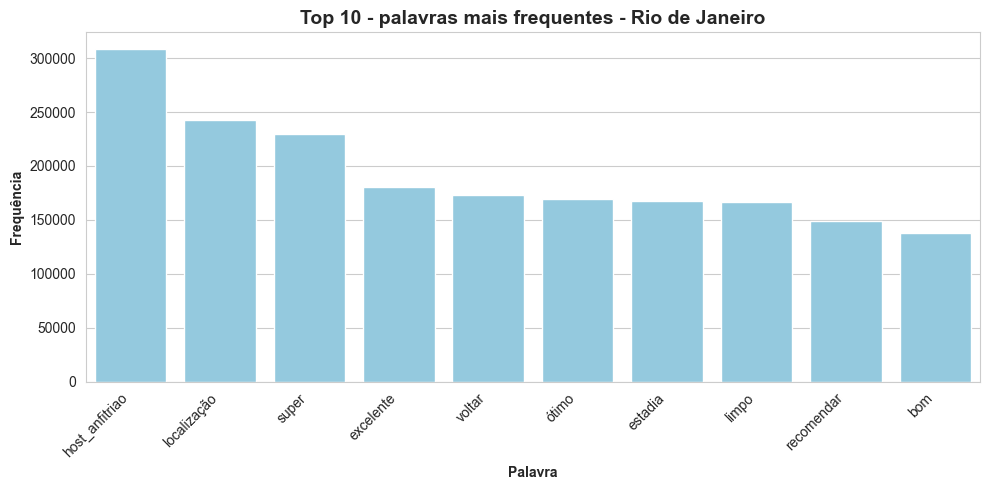

Gráfico de barras para as 10 palavras mais frequentes - Rio de Janeiro salvo como 'top10_freq_palavras_RJ.png'


<Figure size 640x480 with 0 Axes>

In [210]:
# ==========================================    
# Gráfico de barras para as 10 palavras mais frequentes - Rio de Janeiro
# ==========================================
sns.set_style("whitegrid")

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_RJ, x='Palavra', y='Frequência', color='skyblue')

plt.xlabel('Palavra', fontweight='bold')
plt.ylabel('Frequência', fontweight='bold')
plt.title('Top 10 - palavras mais frequentes - Rio de Janeiro', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================================
# Salva o gráfico de barras para as 10 palavras mais frequentes - Rio de Janeiro
# ==========================================
plt.savefig("top10_freq_palavras_RJ.png", dpi=300, bbox_inches="tight")
print("Gráfico de barras para as 10 palavras mais frequentes - Rio de Janeiro salvo como 'top10_freq_palavras_RJ.png'")

In [211]:
# ==========================================
# Remover várias colunas que não são mais necessárias para a modelagem de tópicos
# ==========================================
df_RJ_finalizar = df_RJ_Lematizar.drop(columns=['id', 'listing_id', 'reviewer_id', 'reviewer_name'])
df_RJ_finalizar.head()

,date,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado,texto_lematizado
17,2011-10-04,"Muito Melhor do que ir para um hotel. Apt com excelente localização( 1 quarteirão da praia), muito organizado e limpo. O proprietário sempre muito solicito para resolver qualquer problema. O Apt também tem um terraço maravilhoso. Esta é a melhor maneira de conhecer o RIO\r<br/>\r<br/>",Rio de Janeiro,pt,283,47,Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO,[],Muito Melhor do que ir para um hotel Apt com excelente localização quarteirão da praia muito organizado e limpo O proprietário sempre muito solicito para resolver qualquer problema O Apt também tem um terraço maravilhoso Esta é a melhor maneira de conhecer o RIO,muito melhor do que ir para um hotel apartamento com excelente localização quarteirão da praia muito organizado e limpo o proprietário sempre muito solicito para resolver qualquer problema o apartamento também tem um terraço maravilhoso esta é a melhor maneira de conhecer o rio,bom hotel excelente localização quarteirão praia organizar limpo proprietário solicitar resolver problema terraço maravilhoso bom maneira conhecer rio
18,2011-10-11,"Muito bom o apartamento, a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto.",Rio de Janeiro,pt,111,22,Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,[],Muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,muito bom o apartamento a pouco mais de uma quadra da praia e com muitos lugares para comer e sair por perto,quadra praia lugar comer sair
34,2013-01-28,"O apartamento é maravilhoso, novo, bem decorado, muito bem equipado, possui tudo que se precisa. A localização é perfeita próxima a tudo, tanto de Copacabana quanto Ipanema. Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã. Toda minha família se sentiu acolhida e bem a vontade. Um abraço pra todos e com certeza recomendo este apartamento, como também me hospedarei novamente nele de volta ao Rio.",Rio de Janeiro,pt,454,75,O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do Bernardo durante a negociação e a simpatia e presteza da Vera como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio,"[Bernardo, Vera]",O apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa A localização é perfeita próxima a tudo tanto de Copacabana quanto Ipanema Quero agradecer a atenção do host_anfitriao durante a negociação e a simpatia e presteza da host_anfitriao como anfitriã Toda minha família se sentiu acolhida e bem a vontade Um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao Rio,o apartamento é maravilhoso novo bem decorado muito bem equipado possui tudo que se precisa a localização é perfeita próxima a tudo tanto de copacabana quanto ipanema quero agradecer a atenção do host_anfitriao durante a negociação e a simpatia e presteza da host_anfitriao como anfitriã toda minha família se sentiu acolhida e bem a vontade um a aço pra todos e com certeza recomendo este apartamento como também me hospedarei novamente nele de volta ao rio,maravilhoso decorar equipar possuir precisar localização perfeito copacabana ipanema agradecer atenção host_anfitriao durante negociação simpatia presteza host_anfitriao anfitriã família sentir aco

In [212]:
# ==========================================
# Exibe informações sobre o dataset finalizado do Rio de Janeiro    
# ==========================================
df_RJ_finalizar.info()

<class 'pandas.DataFrame'>
Index: 721089 entries, 17 to 1127714
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   date               721089 non-null  str   
 1   comments           721089 non-null  str   
 2   cidade             721089 non-null  str   
 3   lang               721089 non-null  str   
 4   char_count         721089 non-null  int64 
 5   word_count         721089 non-null  int64 
 6   texto_limpo        721089 non-null  str   
 7   nomes_proprios     721089 non-null  object
 8   texto_anonimizado  721089 non-null  str   
 9   texto_normalizado  721089 non-null  str   
 10  texto_lematizado   721089 non-null  str   
dtypes: int64(2), object(1), str(8)
memory usage: 66.0+ MB


-----
## **Informações do dataset Reviews da cidade do Rio de Janeiro<br> Após o pré-processamento:** 

- Total de Entradas: **721.089**
- Total de Colunas: **11**
- Palavras Únicas Tokenizadas: **55.967**
----------

In [19]:
# ==========================================
# Salva o DataFrame pré-processado em um arquivo pickle, para uso posterior
# ==========================================    
df_RJ_finalizar.to_pickle("Reviews_RJ_Lematizado.pkl")

--------
# **Reviews da Cidade de Lisboa**


-------------
## **Detetar idioma**
--------------

In [11]:
# ==========================================
# Função para detectar o idioma do texto usando a biblioteca langdetect - Lisboa
# ==========================================
def detectar_idioma(texto):
    try:
        texto = str(texto).strip()
        if len(texto) < 3:
            return "UNKNOWN"
        return detect(texto)   # ex: 'pt', 'en', 'es'
    except LangDetectException:
        return "UNKNOWN"
    
# ==========================================
# Aplica a função de detecção de idioma ao dataset de Lisboa, criando uma nova coluna "lang"
# ==========================================
reviews_Lisboa["lang"] = reviews_Lisboa["comments"].apply(detectar_idioma)

In [12]:
reviews_Lisboa.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang
0,1113142,60014456,2016-01-18,35314589,Andre,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.,Lisboa,pt
1,1113142,86635385,2016-07-17,36799194,Daniele,Perfect host. Everything was fine. I will certainly go there again when I'm back in Lisbon,Lisboa,en
2,1113142,94639801,2016-08-16,1826748,Sibtain,"All in all, it was a very good, modern apartment and the host was friendly & helpful (we had a small problem once and the response was swift). It was adequately furnished & equipped. Everything that was promised on the webpage was available. Weekly cleaning was certainly a plus. The location was central, just a few minutes drive to all shopping malls & even city center (supermarket & cafes nearby). The metro station is just a few minutes walk away. It was also not far from the airport. We always managed to find a parking for the car right at the building. We would like to thank again the host for everything. I would certainly recommend the apartment to anyone visiting Lisbon.",Lisboa,en
3,1113142,112991958,2016-11-09,5985047,Nathan,Lovely apartment and frictionless stay. Booked the apartment for a work trip and at one point had to cancel and rebook which was not a problem. <br/>Lovely clean apartment and just what we required. The area has some nice coffee shops and restaurants and is very near the airport. <br/>,Lisboa,en
4,1113142,215013241,2017-11-27,154490966,Agenor,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.,Lisboa,pt


In [13]:
# ==========================================
# Salva o dataset atualizado com a nova coluna "lang"
# ==========================================
reviews_Lisboa.to_csv("reviews_Lisboa_lang.csv", index=False)

-----
## **Contar a Frequencia de cada idioma**
-------

In [14]:
# ==========================================
# Exibe a frequência dos idiomas detectados 
# ==========================================
freq_lang_Lisboa = reviews_Lisboa["lang"].value_counts()
freq_lang_Lisboa

lang
en         1051431
fr          257874
pt          124783
es          109423
de           89235
it           34071
nl           24949
ko            9965
UNKNOWN       6823
ru            6143
zh-cn         5950
ro            4554
pl            4374
da            3678
ca            3592
sv            3270
no            2494
cs            1910
so            1814
af            1723
fi            1494
tr            1480
he            1332
hu            1197
ja            1187
id             929
tl             906
cy             903
uk             882
el             752
zh-tw          725
hr             668
lt             563
sk             544
sw             388
ar             288
sl             267
et             207
bg             182
lv             143
vi             136
mk              50
sq              37
th               8
ur               7
fa               4
ne               2
hi               1
kn               1
mr               1
bn               1
Name: count, dtype: int64

------
## **Grafico de Barras para mostrar o top 5 da frequencia de cada idioma**
--------

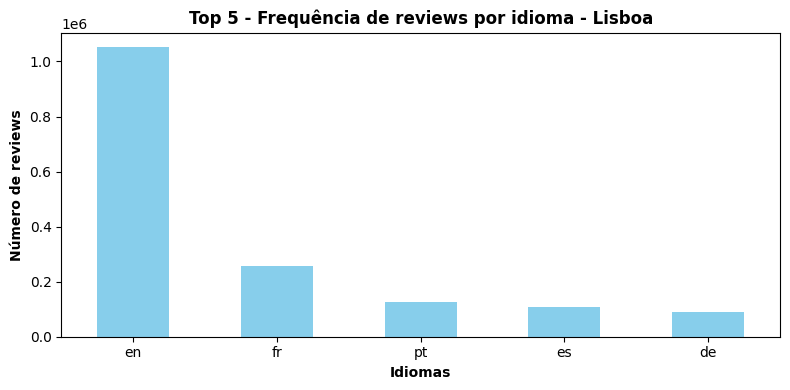

Gráfico de barras para a frequência de idiomas Top 5 - Lisboa salvo como 'frequencia_idiomas_Lisboa.png'


<Figure size 640x480 with 0 Axes>

In [15]:
# ==========================================
# Gráfico de barras para a frequência de idiomas Top 5 - Lisboa
# ==========================================
plt.figure(figsize=(8, 4))

freq_lang_Lisboa.sort_values(ascending=False).head(5).plot(
    kind="bar", color="skyblue"
)

plt.xlabel("Idiomas", fontweight="bold")
plt.ylabel("Número de reviews", fontweight="bold")
plt.title("Top 5 - Frequência de reviews por idioma - Lisboa", fontsize=12, fontweight="bold")
plt.xticks(rotation=0)
plt.grid(False)
plt.tight_layout()
plt.show()

# ==========================================
# Salva o grafico de barras para a frequência de idiomas Top 5 - Lisboa
# ==========================================
plt.savefig("frequencia_idiomas_Lisboa.png", dpi=300, bbox_inches="tight")
print("Gráfico de barras para a frequência de idiomas Top 5 - Lisboa salvo como 'frequencia_idiomas_Lisboa.png'")

-----
## **Reviews da cidade de Lisboa em PORTUGUES:**
-----

In [16]:
# ==========================================
# Filtra as reviews em português
# ==========================================
reviews_Lisboa_pt = reviews_Lisboa[reviews_Lisboa["lang"] == "pt"].copy()

reviews_Lisboa_pt.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang
0,1113142,60014456,2016-01-18,35314589,Andre,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.,Lisboa,pt
4,1113142,215013241,2017-11-27,154490966,Agenor,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.,Lisboa,pt
6,1113142,577387176,2019-12-15,15145286,Nath,"O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada. No entanto, tive sérios problemas com o proprietário : mudaram a data do meu check in no dia que eu cheguei - eu viajei com toda minha família e tenho um bebe com menos de 2 anos. Há quedas correntes de energia. E a proprietária me cobrou de algo absurdo: o vidro do box que protege a área de banho se trincou sozinho. Poderia ter causado um enorme acidente ao meu filho e demais membros da família. E a proprietária insiste em me cobrar o valor como se eu ou alguém tivéssemos feito algo. Um técnico foi ao local e confirmou que isso acontecia com o tempo, fiz até um video do vidro se despedaçando. Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de ""desculpas"",. veio uma cobrança. Muito absurdo.",Lisboa,pt
12,6499,18879225,2014-09-02,17027029,Simone,"Ola Bruno,\r<br/>\r<br/>Tive um mes Fantástico em seu apartamento. O apartamento realmente está bem situado. Um elétrico passa a cada 15 min. em frente, bem como várias linhas de autocarro. Isto facilita para ir ao Centro de Lisboa. Pontos turísticos e restaurantes bem próximos.\r<br/>Apartamento aconchegante com facilidade em organizá-lo. Ótimo acesso a internet. Boa vizinhança.\r<br/>Sempre tive apoio do anfitriao Bruno, bem como otima comunicao online. Esteve sempre auxiliando e buscou resolver de imediato coisas inesperadas no apartamento.\r<br/>\r<br/>Obrigado! Até à próxima oportunidade de estar em Lisboa.",Lisboa,pt
13,6499,21074122,2014-10-11,7661611,Cláudio,"Encontramos o apartamento de Bruno exatamente conforme a descrição e as fotos, além de muito bem limpo, cuidado com muito carinho e equipado com tudo o que é necessário e prático. Lençóis e toalhas disponíveis, travesseiros e uma cama extremamente confortável. A localização é incrível, segura e perfeita para visitar Lisboa. Todos os monumentos e locais históricos de Belém estão a alguns minutos da caminhada mais agradável da cidade, em meio a jardins, praças e restaurantes, e muitas opções de transportes para as outras zonas estão à porta do prédio. Numa estada mais extensa, como a nossa, é importante que o anfitrião esteja sempre ao alcance, e a atenção e a disponibilidade de Bruno realmente impressionam. Nenhuma de nossas comunicações e nenhum pequeno ajuste ou providência que foi necessária demorou mais do que alguns minutos. Uma de nossas melhores experiências no AirBnb.",Lisboa,pt


In [17]:
# ==========================================
# Salvar o DataFrame filtrado em um arquivo pickle
# ==========================================
reviews_Lisboa_pt.to_pickle("reviews_Lisboa_pt.pkl")

------------
## **Pré-processamento dos Reviews**

----------

In [145]:
# ==========================================
# Importar os datasets "reviews_Lisboa_pt.pkl" da cidade de Lisboa
# ==========================================
df_Lisboa_pt = pd.read_pickle("reviews_Lisboa_pt.pkl")
df_Lisboa_pt.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang
0,1113142,60014456,2016-01-18,35314589,Andre,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.,Lisboa,pt
4,1113142,215013241,2017-11-27,154490966,Agenor,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.,Lisboa,pt
6,1113142,577387176,2019-12-15,15145286,Nath,"O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada. No entanto, tive sérios problemas com o proprietário : mudaram a data do meu check in no dia que eu cheguei - eu viajei com toda minha família e tenho um bebe com menos de 2 anos. Há quedas correntes de energia. E a proprietária me cobrou de algo absurdo: o vidro do box que protege a área de banho se trincou sozinho. Poderia ter causado um enorme acidente ao meu filho e demais membros da família. E a proprietária insiste em me cobrar o valor como se eu ou alguém tivéssemos feito algo. Um técnico foi ao local e confirmou que isso acontecia com o tempo, fiz até um video do vidro se despedaçando. Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de ""desculpas"",. veio uma cobrança. Muito absurdo.",Lisboa,pt
12,6499,18879225,2014-09-02,17027029,Simone,"Ola Bruno,\r<br/>\r<br/>Tive um mes Fantástico em seu apartamento. O apartamento realmente está bem situado. Um elétrico passa a cada 15 min. em frente, bem como várias linhas de autocarro. Isto facilita para ir ao Centro de Lisboa. Pontos turísticos e restaurantes bem próximos.\r<br/>Apartamento aconchegante com facilidade em organizá-lo. Ótimo acesso a internet. Boa vizinhança.\r<br/>Sempre tive apoio do anfitriao Bruno, bem como otima comunicao online. Esteve sempre auxiliando e buscou resolver de imediato coisas inesperadas no apartamento.\r<br/>\r<br/>Obrigado! Até à próxima oportunidade de estar em Lisboa.",Lisboa,pt
13,6499,21074122,2014-10-11,7661611,Cláudio,"Encontramos o apartamento de Bruno exatamente conforme a descrição e as fotos, além de muito bem limpo, cuidado com muito carinho e equipado com tudo o que é necessário e prático. Lençóis e toalhas disponíveis, travesseiros e uma cama extremamente confortável. A localização é incrível, segura e perfeita para visitar Lisboa. Todos os monumentos e locais históricos de Belém estão a alguns minutos da caminhada mais agradável da cidade, em meio a jardins, praças e restaurantes, e muitas opções de transportes para as outras zonas estão à porta do prédio. Numa estada mais extensa, como a nossa, é importante que o anfitrião esteja sempre ao alcance, e a atenção e a disponibilidade de Bruno realmente impressionam. Nenhuma de nossas comunicações e nenhum pequeno ajuste ou providência que foi necessária demorou mais do que alguns minutos. Uma de nossas melhores experiências no AirBnb.",Lisboa,pt


In [146]:
# ==========================================
# Verificar valores nulos
# ==========================================
print("Valores nulos por coluna:\n", df_Lisboa_pt.isnull().sum())

Valores nulos por coluna:
 listing_id       0
id               0
date             0
reviewer_id      0
reviewer_name    3
comments         0
cidade           0
lang             0
dtype: int64


In [147]:
# ==========================================
# Conta quantas linhas duplicadas existem no dataset filtrado para português
# ==========================================
print("Número de linhas duplicadas:", df_Lisboa_pt.duplicated().sum())

Número de linhas duplicadas: 0


In [148]:
# ==========================================
# Descrição estatistica do número de caracteres e palavras
# ==========================================
df_Lisboa_pt['char_count'] = df_Lisboa_pt['comments'].astype(str).apply(len)
df_Lisboa_pt['word_count'] = df_Lisboa_pt['comments'].astype(str).apply(lambda x: len(x.split()))
print(df_Lisboa_pt[['char_count', 'word_count']].describe())

          char_count     word_count
count  124783.000000  124783.000000
mean      208.729659      33.177893
std       201.592825      33.488494
min         3.000000       1.000000
25%        75.000000      11.000000
50%       150.000000      23.000000
75%       275.000000      44.000000
max      4450.000000     725.000000


-----
## **Função única de limpeza textual para remover quebras de linhas, tags HTML, números, pontuação e caracteres especiais que atrapalham a semântica do texto.**
------

In [149]:
# ==========================================
# Função única de limpeza textual
# ==========================================
nlp = spacy.load("pt_core_news_lg")


def limpar_texto(texto):
    texto = str(texto)

    # Remover quebras de linha e tags HTML simples
    texto = texto.replace("\\r<br/>", " ")
    texto = texto.replace("<br/>", " ")
    texto = texto.replace("br", " ")

    # Remover tags HTML genéricas
    texto = re.sub(r"<.*?>", " ", texto)

    # Remover números
    texto = re.sub(r"\d+", " ", texto)

    # Remover pontuação e caracteres especiais, mantendo letras acentuadas e espaços
    texto = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", texto)

    # Remover espaços múltiplos
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()

df_Lisboa_pt["texto_limpo"] = df_Lisboa_pt["comments"].apply(limpar_texto)
df_Lisboa_pt.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang,char_count,word_count,texto_limpo
0,1113142,60014456,2016-01-18,35314589,Andre,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.,Lisboa,pt,137,21,Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária
4,1113142,215013241,2017-11-27,154490966,Agenor,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.,Lisboa,pt,97,13,Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios
6,1113142,577387176,2019-12-15,15145286,Nath,"O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada. No entanto, tive sérios problemas com o proprietário : mudaram a data do meu check in no dia que eu cheguei - eu viajei com toda minha família e tenho um bebe com menos de 2 anos. Há quedas correntes de energia. E a proprietária me cobrou de algo absurdo: o vidro do box que protege a área de banho se trincou sozinho. Poderia ter causado um enorme acidente ao meu filho e demais membros da família. E a proprietária insiste em me cobrar o valor como se eu ou alguém tivéssemos feito algo. Um técnico foi ao local e confirmou que isso acontecia com o tempo, fiz até um video do vidro se despedaçando. Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de ""desculpas"",. veio uma cobrança. Muito absurdo.",Lisboa,pt,814,150,O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo
12,6499,18879225,2014-09-02,17027029,Simone,"Ola Bruno,\r<br/>\r<br/>Tive um mes Fantástico em seu apartamento. O apartamento realmente está bem situado. Um elétrico passa a cada 15 min. em frente, bem como várias linhas de autocarro. Isto facilita para ir ao Centro de Lisboa. Pontos turísticos e restaurantes bem próximos.\r<br/>Apartamento aconchegante com facilidade em organizá-lo. Ótimo acesso a internet. Boa vizinhança.\r<br/>Sempre tive apoio do anfitriao Bruno, bem como otima comunicao online. Esteve sempre auxiliando e buscou resolver de imediato coisas inesperadas no apartamento.\r<br/>\r<br/>Obrigado! Até à próxima oportunidade de estar em Lisboa.",Lisboa,pt,614,90,Ola Bruno Tive um mes Fantástico em seu apartamento O apartamento realmente está bem situado Um elétrico passa a cada min em frente bem como várias linhas de autocarro Isto facilita para ir ao Centro de Lisboa Pontos turísticos e restaurantes bem próximos Apartamento aconchegante com facilidade em organizá lo Ótimo acesso a internet Boa vizinhança Sempre tive apoio do anfitriao Bruno bem como otima comunicao online Esteve sempre auxiliando e buscou resolver de imediato coisas inesperadas no apartamento O igado Até à próxima oportunidade de estar em Lisboa
13,6499,21074122,2014-10-11,7661611,Cláudio,"Encontramos o apartamento de Bruno exatamente conforme a descrição e as fotos, além de muito bem limpo, cuidado com muito carinho e equipado com tudo o que é necessário e prático. Lençóis e toalhas disponíveis, travesseiros e uma cama extremamente confortável. A localização é incrível, segura e perfeita para visitar Lisboa. Todos os monumentos e l

--------
## **Anonimatizar nomes próprios de anfitriões:**

- Detectar nomes próprios
- Criar uma lista de nomes próprios
- Anonimizar esses nomes
- Substituídos por "host_anfitriao"

-------

In [151]:
# ==========================================
# carrega o modelo de linguagem portuguesa para spaCy e guarda na variável nlp
# ==========================================
nlp = spacy.load("pt_core_news_lg")

# ==========================================
# Função de extração de nomes próprios, já com texto pré‑limpo
# ==========================================
def extrair_nomes_proprios(texto):
    texto_limpo = limpar_texto(texto)       # Primeiro limpa o texto
    doc = nlp(texto_limpo)                  # Extrai apenas entidades com label PER (pessoas)
    
    return [ent.text for ent in doc.ents if ent.label_ == "PER"]

# ==========================================
# Aplica sobre a coluna texto_limpo
# ==========================================
df_Lisboa_pt["nomes_proprios"] = df_Lisboa_pt["texto_limpo"].apply(extrair_nomes_proprios)

In [152]:
# ==========================================
# transforma cada elemento de lista numa linha individual, gerando uma série plana de todos os nomes
# ==========================================
todos_nomes = df_Lisboa_pt["nomes_proprios"].explode().dropna()

# ==========================================
# Contar frequência de cada nome
# ==========================================
contagem_nomes = Counter(todos_nomes.dropna())

# ==========================================
# Obter os 100 nomes mais frequentes e suas contagens
# ==========================================
top_100 = contagem_nomes.most_common(100)

# ==========================================
# Somar a repetição desses 100 primeiros nomes
# ==========================================
soma_top_100 = sum(contagem for nome, contagem in top_100)

print("100 nomes mais frequentes:")
for nome, contagem in top_100:
    print(f"{nome}: {contagem}")

print(f"\nSoma de repetições dos 100 primeiros nomes mais frequentes: {soma_top_100}")

100 nomes mais frequentes:
Ana: 2188
Maria: 1817
Pedro: 1720
Ótima: 1685
Anfitrião: 1321
João: 950
Nuno: 916
José: 738
Anfitriã: 729
Isabel: 715
Casa: 699
Miguel: 669
Joana: 581
Adorei: 570
Gostei: 562
Amei: 535
Carlos: 524
Agradeço: 485
Teresa: 472
Sofia: 449
Rui: 445
Parabéns: 444
Anfitriões: 424
Único: 406
Patrícia: 386
Tiago: 385
Inês: 380
Marta: 367
Filipe: 365
Paula: 334
Carla: 309
Luís: 308
Diogo: 304
Margarida: 301
Bruno: 291
Agradecemos: 288
Susana: 285
Alexandre: 282
Luis: 280
Rita: 279
Paulo: 263
Alexandra: 253
Helena: 245
Catarina: 240
Hugo: 237
Sara: 233
Filipa: 228
Francisco: 224
Apto: 221
Antônio: 220
Jorge: 217
Claudia: 215
Achei: 212
Rafael: 211
Ricardo: 209
Fernanda: 195
David: 189
Fui: 187
Rodrigo: 185
Cristina: 179
Elsa: 174
Bárbara: 170
Frederico: 169
Daniel: 165
Henrique: 161
António: 158
Nossa: 157
Manuel: 147
Vera: 144
Fernando: 143
Gonçalo: 141
Cândida: 139
A Ana: 135
André: 122
Sérgio: 117
Vitor: 116
Gustavo: 116
Me: 112
Liliana: 112
Minha: 111
Ótimo: 110
Cláu

In [153]:
# ==========================================
# Lista de todos os nomes próprios do dataset, sem repetições
# ==========================================
nomes_unicos = (
    df_Lisboa_pt["nomes_proprios"]
    .explode()
    .dropna()
    .drop_duplicates()
)

# ==========================================
# Converter para set para usar em substituição
# ==========================================
nomes_alvo = set(nomes_unicos)

print(f"Nomes próprios distintos encontrados: {len(nomes_alvo)}")


Nomes próprios distintos encontrados: 8310


In [154]:
# ==========================================
# Remover manualmente todas as palavras que não são nomes próprios, que a funcão não conseguiu detetar
# ==========================================
palavras_a_excluir = {"Ótima", "ótimas", "Ótimas", "Óptima", "Ótimo", "Óptimo", "Ótimos", "ótimos", "otimo", "otima", "otimos", "otimas", "Anfitrião", "anfitriao", "anfitrião", "anfitriã", "Anfitriã", "anfitria", "Gostei", "gostei", "Gostamos", "Agradeço", "Agradecemos", "Super", "Precisa", "agradeço", "Agradecer", "Grato", "Amei", "amei", "Parabéns", "Parabens", "parabens", "Anfitriões", "Anfitrões", "Adorei", "adorei", "Achei", "Único", "Casa", "casa", "Checkin", "checkin", "chekout", "Chekout", "Muitíssimo", "muitíssimo", "Apto limpo", "Atenciosa", "atenciosa", "Simpático", "Gentil", "Simpática", "Difícil", "Volto", "Fantástico", "Perfeita", "Boas", "Satisfeito", "Magnífico", "Casa linda", "Adoraria", "PERFEITA", "Senti-me", "Silêncio", "Supriu", "Gracias", "Recebeu-nos", "Vc", "Idêntico", "msgs", "Solicitei", "Quero", "Queria", "cómodo", "Cómodo", "Fui", "Apto", "Ambiente", "Vamos", "Voltaria", "Voltaríamos", "Confortável", "Grata", "Perfeito", "Incrível", "Melhor", "Apartamento", "Cama confortável", "Roupas", "Quarto", "Quartos", "Inclusive", "Limpeza", "Desejo", "Impecável", "Lugar", "Confesso", "Condiz", "Queríamos", "Amplo", "Janela", "Portas", "Percebe", "Correspondeu", "Nada", "Únicos", "Seguro", "Parecia", "Permitiu", "Estrelas", "Dormimos", "Acho", "Pequeno", "Grande", "Disseram", "Fabulous", "Gentileza", "Simplesmente", "Estela", "Comuniquei", "Proprietária", "confortável Voltaria", "Prático", "Espero", "Fico", "Adorámos", "Poderia", "mem"}
todos_nomes = df_Lisboa_pt["nomes_proprios"].explode().dropna()
nomes_serie = todos_nomes[~todos_nomes.isin(palavras_a_excluir)]

contagem_nomes = Counter(nomes_serie)
top_500 = contagem_nomes.most_common(500)

print("500 nomes próprios mais frequentes (sem 'Ótima' e termos genéricos):")
for nome, frequencia in top_500:
    print(f"{nome}: {frequencia}")

500 nomes próprios mais frequentes (sem 'Ótima' e termos genéricos):
Ana: 2188
Maria: 1817
Pedro: 1720
João: 950
Nuno: 916
José: 738
Isabel: 715
Miguel: 669
Joana: 581
Carlos: 524
Teresa: 472
Sofia: 449
Rui: 445
Patrícia: 386
Tiago: 385
Inês: 380
Marta: 367
Filipe: 365
Paula: 334
Carla: 309
Luís: 308
Diogo: 304
Margarida: 301
Bruno: 291
Susana: 285
Alexandre: 282
Luis: 280
Rita: 279
Paulo: 263
Alexandra: 253
Helena: 245
Catarina: 240
Hugo: 237
Sara: 233
Filipa: 228
Francisco: 224
Antônio: 220
Jorge: 217
Claudia: 215
Rafael: 211
Ricardo: 209
Fernanda: 195
David: 189
Rodrigo: 185
Cristina: 179
Elsa: 174
Bárbara: 170
Frederico: 169
Daniel: 165
Henrique: 161
António: 158
Nossa: 157
Manuel: 147
Vera: 144
Fernando: 143
Gonçalo: 141
Cândida: 139
A Ana: 135
André: 122
Sérgio: 117
Vitor: 116
Gustavo: 116
Me: 112
Liliana: 112
Minha: 111
Cláudia: 108
Mário: 106
Antonio: 104
Diana: 104
Raquel: 104
Felipe: 102
Manuela: 102
Anabela: 100
Cama: 97
Fátima: 97
Sarah: 95
Helder: 93
Tomás: 92
Fábio: 92
Au

In [155]:
# ==========================================
# Encontrar linhas com "Gentil" (ou variações) para esclarecer dúvida se a palavra é um nome próprio ou um adjetivo
# ==========================================
mask = df_Lisboa_pt["texto_limpo"].str.contains("Gentil", case=True, na=False)

# ==========================================
# Exibir até 5 linhas com o texto completo
# ==========================================
exemplos = df_Lisboa_pt.loc[mask, "texto_limpo"].head(5)

print("Reviews com a palavra 'Gentil' (texto completo):\n")
for i, texto in enumerate(exemplos, start=1):
    print(f"{i}) {texto}\n")

Reviews com a palavra 'Gentil' (texto completo):

1) Excelente localização Apartamento tal como está nas fotos Gentileza do Luis

2) Local simpático agradável extremamente limpo O check in foi realizado pessoalmente com o pai de Miguel e checkout muito tranquilo Gentileza e atenção em todos os momentos Indico certamente esta hospedagem

3) Já estou com saudades do apartamento do Nuno Muito bem localizado Próximo de duas estações de comboios e metro Próximo de estação de autocarros de shoping restaurantes supermercados Tudo muito perto O apartamento está decorado com muito bom gosto e totalmente equipado Fiquei dias neste apartamento Recomendo vivamente Nuno é excelente anfitrião É seguramente um dos melhores que conheci Gentil educado e sempre pronto a nos ajudar O igado Voltaremos

4) O acolhimento da Sílvia foi excepcional Gentil generosa e sempre muito disponível Nos deixou muito a vontade durante nossa estada O apartamento é incrível totalmente reformado por ela e super confortável

In [156]:
total_ocorrencias = sum(contagem_nomes.values())
print("Total de ocorrências dos nomes (após exclusões):", total_ocorrencias)

Total de ocorrências dos nomes (após exclusões): 46688


In [157]:
# ==========================================
# Removem‑se os valores ausentes com o método, conta‑se o número de elementos únicos utilizando
# ==========================================
num_nomes_distintos = nomes_serie.dropna().nunique() 
nomes_unicos = sorted(nomes_serie.dropna().unique())
total_ocorrencias = sum(contagem_nomes.values())
top_10 = contagem_nomes.most_common(10)
soma_top_10 = sum(freq for _, freq in top_10)
percent_top_10 = soma_top_10 / total_ocorrencias * 100 if total_ocorrencias else 0

print(f"Nomes distintos (após exclusão): {num_nomes_distintos}\n")
print("Top 10 nomes mais frequentes:")
for nome, freq in top_10:
    print(f"{nome}: {freq}")
print(f"\nSoma Top 10: {soma_top_10} ({percent_top_10:.2f}% do total de ocorrências)\n")
print("Exemplos de nomes distintos (primeiros 50):")
print(nomes_unicos[:50])

Nomes distintos (após exclusão): 8196

Top 10 nomes mais frequentes:
Ana: 2188
Maria: 1817
Pedro: 1720
João: 950
Nuno: 916
José: 738
Isabel: 715
Miguel: 669
Joana: 581
Carlos: 524

Soma Top 10: 10818 (23.17% do total de ocorrências)

Exemplos de nomes distintos (primeiros 50):
['A', 'A Alzira Maria Anfitriã', 'A Ana', 'A Ana Clara', 'A Ana Cristina', 'A Ana Luísa', 'A Ana Lúcia', 'A Ana Paula', 'A Ana Raquel', 'A Ana Rita', 'A Ana està', 'A Ana o José', 'A Anabela', 'A Andreia', 'A Anfitriã', 'A Anne', 'A Bárbara', 'A Carey', 'A Carla', 'A Carmem', 'A Carolina', 'A Casa', 'A Casa Amarela', 'A Cassie', 'A Catarina', 'A Celia', 'A Cintia', 'A Clara', 'A Connie', 'A Cíntia', 'A Daniela', 'A Diana', 'A Dinah', 'A Dolores', 'A Dona Ana', 'A Eliana', 'A Elizabete', 'A Emma', 'A Estelle', 'A Esther', 'A Fernanda', 'A Filipa', 'A Flávia', 'A Fátima', 'A Gal', 'A Hanifa', 'A Inês', 'A Isabel', 'A Isabelle', 'A Ivone']


In [158]:
# ==========================================
# Filtrar nomes_proprios excluindo as palavras indesejadas
# ==========================================
def filtrar_nomes_proprios(lista_nomes):
    if isinstance(lista_nomes, list):
        return [nome for nome in lista_nomes if nome not in palavras_a_excluir]
    return []

df_Lisboa_pt["nomes_proprios"] = df_Lisboa_pt["nomes_proprios"].apply(filtrar_nomes_proprios)

# Verificar se fo existem na contagem filtrada
todos_nomes = df_Lisboa_pt["nomes_proprios"].explode().dropna()
nomes_serie = todos_nomes[~todos_nomes.isin(palavras_a_excluir)]  # redundante, mas para confirmação
contagem_nomes = Counter(nomes_serie)
top_500 = contagem_nomes.most_common(500)

# Verificar contagem de "Ótima" após filtragem
print("Ocorrências de 'Ótima' após filtragem:", contagem_nomes.get("Ótima", 0))

Ocorrências de 'Ótima' após filtragem: 0


In [159]:
df_Lisboa_pt.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios
0,1113142,60014456,2016-01-18,35314589,Andre,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.,Lisboa,pt,137,21,Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária,[Inês]
4,1113142,215013241,2017-11-27,154490966,Agenor,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.,Lisboa,pt,97,13,Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios,[]
6,1113142,577387176,2019-12-15,15145286,Nath,"O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada. No entanto, tive sérios problemas com o proprietário : mudaram a data do meu check in no dia que eu cheguei - eu viajei com toda minha família e tenho um bebe com menos de 2 anos. Há quedas correntes de energia. E a proprietária me cobrou de algo absurdo: o vidro do box que protege a área de banho se trincou sozinho. Poderia ter causado um enorme acidente ao meu filho e demais membros da família. E a proprietária insiste em me cobrar o valor como se eu ou alguém tivéssemos feito algo. Um técnico foi ao local e confirmou que isso acontecia com o tempo, fiz até um video do vidro se despedaçando. Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de ""desculpas"",. veio uma cobrança. Muito absurdo.",Lisboa,pt,814,150,O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo,[]
12,6499,18879225,2014-09-02,17027029,Simone,"Ola Bruno,\r<br/>\r<br/>Tive um mes Fantástico em seu apartamento. O apartamento realmente está bem situado. Um elétrico passa a cada 15 min. em frente, bem como várias linhas de autocarro. Isto facilita para ir ao Centro de Lisboa. Pontos turísticos e restaurantes bem próximos.\r<br/>Apartamento aconchegante com facilidade em organizá-lo. Ótimo acesso a internet. Boa vizinhança.\r<br/>Sempre tive apoio do anfitriao Bruno, bem como otima comunicao online. Esteve sempre auxiliando e buscou resolver de imediato coisas inesperadas no apartamento.\r<br/>\r<br/>Obrigado! Até à próxima oportunidade de estar em Lisboa.",Lisboa,pt,614,90,Ola Bruno Tive um mes Fantástico em seu apartamento O apartamento realmente está bem situado Um elétrico passa a cada min em frente bem como várias linhas de autocarro Isto facilita para ir ao Centro de Lisboa Pontos turísticos e restaurantes bem próximos Apartamento aconchegante com facilidade em organizá lo Ótimo acesso a internet Boa vizinhança Sempre tive apoio do anfitriao Bruno bem como otima comunicao online Esteve sempre auxiliando e buscou resolver de imediato coisas inesperadas no apartamento O igado Até à próxima oportunidade de estar em Lisboa,[Bruno]
13,6499,21074122,2014-10-11,7661611,Cláudio,"Encontramos o apartamento de Bruno exatamente conforme a descrição e as fotos, além de muito bem limpo, cuidado com muito carinho e equipado com tudo o que é necessário e prático. Lençóis e toalhas disponíveis, travesseiros e uma cama extremamente confortável. A localização é incrível, segura e perfeita para vis

In [160]:
# ==========================================
# cria um novo DataFrame para normalização, mantendo o original intacto, criando uma cópia de segurança
# ==========================================
df_Lisboa_anonimizar = df_Lisboa_pt.copy()

In [162]:
# ==========================================
# Funcao para Aninimizar os nomes próprios para a palavra "host_anfitriao"
# ==========================================
def anonimizar_nomes(texto, nomes_proprios):
    texto_out = str(texto)
    
    nomes_ord = sorted(nomes_proprios, key=len, reverse=True)   # Ordenar nomes do maior para o menor para evitar substituir parte de outro nome
    for nome in nomes_ord:
        
        texto_out = re.sub(
            r"\b" + re.escape(nome) + r"\b",                    # \b garante borda de palavra, evitando alterar partes de outras palavras
            "host_anfitriao",
            texto_out,
            flags=re.IGNORECASE
        )
    return texto_out.strip()

    # ==========================================
    # Cria coluna texto_anonimizado a partir de texto_limpo e nomes_proprios
    #==========================================
df_Lisboa_anonimizar["texto_anonimizado"] = df_Lisboa_anonimizar.apply(
    lambda row: anonimizar_nomes(row["texto_limpo"], row["nomes_proprios"]),
    axis=1
)

df_Lisboa_anonimizar[["texto_limpo", "nomes_proprios", "texto_anonimizado"]]

,texto_limpo,nomes_proprios,texto_anonimizado
0,Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária,[Inês],Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela host_anfitriao que nos prestou toda a assistência necessária
4,Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios,[],Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios
6,O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo,[],O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo
12,Ola Bruno Tive um mes Fantástico em seu apartamento O apartamento realmente está bem situado Um elétrico passa a cada min em frente bem como várias linhas de autocarro Isto facilita para ir ao Centro de Lisboa Pontos turísticos e restaurantes bem próximos Apartamento aconchegante com facilidade em organizá lo Ótimo acesso a internet Boa vizinhança Sempre tive apoio do anfitriao Bruno bem como otima comunicao online Esteve sempre auxiliando e buscou resolver de imediato coisas inesperadas no apartamento O igado Até à próxima oportunidade de estar em Lisboa,[Bruno],Ola host_anfitriao Tive um mes Fantástico em seu apartamento O apartamento realmente está bem situado Um elétrico passa a cada min em frente bem como várias linhas de autocarro Isto facilita para ir ao Centro de Lisboa Pontos turísticos e restaurantes bem próximos Apartamento aconchegante com facilidade em organizá lo Ótimo acesso a internet Boa vizinhança Sempre tive apoio do anfitriao host_anfitriao bem como otima comunicao online Esteve sempre auxiliando e buscou resolver de imediato coisas inesperadas no apartamento O igado Até à próxima oportunidade de estar em Lisboa
13,Encontramos o apartamento de Bruno exatamente conforme a descrição e as fotos além de muito bem limpo cuidado com muito carinho e equipado com tudo o que é necessário e prático Lençóis e toalhas disponíveis travesseiros e uma cama extremamente confortável A localização é incrível segura e perfeita para visitar Lisboa Todos os monumentos e locais históricos de Belém estão a alguns minutos da caminhada mais agradável da cidade em meio a jardins praças e restaurantes e muitas opções de transportes para as outras zonas estão à porta do prédio Numa estada mais extensa como a nossa é importante que o anfitrião esteja sempre ao alcance e a atenção e a disponibilidade de Bruno realmente impressionam Nenhuma de nossas comunicações e n

------
## **Normalizar a palavra "apartamento"**
--------

In [163]:
# ==========================================
# cria um novo DataFrame para normalização, mantendo o original intacto, criando uma cópia de segurança
# ==========================================
df_Lisboa_normalizar = df_Lisboa_anonimizar.copy()

In [ ]:
# ==========================================
# Contagem de palavras-chave relacionadas a "apartamento" e suas variações
# ==========================================
texto_todo = " ".join(df_Lisboa_normalizar["texto_anonimizado"].astype(str)).lower()  

# ==========================================
# separa em palavras (tokens) simples
# ==========================================
tokens = re.findall(r"\b\w+\b", texto_todo) # \b\w+\b corresponde a palavras inteiras, ignorando pontuação e espaços
contagem = Counter(tokens)                  

alvos = ["ap", "apto", "apartamento", "apartamentos", "apart", "apt", "ap."]

# ==========================================
# Imprime a contagem de cada variação de "apartamento"
# ==========================================
for palavra in alvos:
    print(palavra, "→", contagem.get(palavra, 0))

ap → 479
apto → 3111
apartamento → 57005
apartamentos → 459
apart → 23
apt → 411
ap. → 0


----
## A palavra **"apartamento"** possui variações, tais como:
- ap
- apto
- apartamento
- apartamentos
- apart
- apt

### Então, será preciso ser feito uma normalização e agrupamento para que todas as formas desta palavra fiquem iguais.
------

In [165]:
# ==========================================
# Contagem de palavras-chave relacionadas a "apartamento" e suas variações
# ==========================================
sinonimos_apto_Lisboa = ["ap", "apto", "apartamento", "apartamentos", "apart", "apt", "ap."]

total_apartamento_Lisboa = sum(contagem.get(p, 0) for p in sinonimos_apto_Lisboa)
print("Total grupo 'apartamento':", total_apartamento_Lisboa)

Total grupo 'apartamento': 61488


In [166]:
# ==========================================
# Função para normalizar o texto completo, convertendo para minúsculas e substituindo variações de "apartamento" por uma forma padrão.
# ==========================================
def normalizar_texto(texto):
    texto = str(texto).lower()
    
    # tokenizar em palavras
    palavras = texto.split()
    
    # normalizar cada palavra
    palavras_norm = [agrupar_apartamento(palavra) for palavra in palavras]
    
    # juntar de volta
    return " ".join(palavras_norm)

# ==========================================
# Função para normalizar variações de "apartamento"
# ==========================================
def agrupar_apartamento(token):
    mapa = {
        "ap": "apartamento",
        "ap.": "apartamento",
        "apto": "apartamento",
        "apt": "apartamento",
        "apart": "apartamento",
        "apartamento": "apartamento",
        "apartamentos": "apartamento",
    }
    return mapa.get(token, token)

In [167]:
# ==========================================
# # Normalização do texto completo, aplicando a função linha a linha
# ==========================================
df_Lisboa_normalizar["texto_normalizado"] = df_Lisboa_normalizar["texto_anonimizado"].apply(normalizar_texto)
df_Lisboa_normalizar.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado
0,1113142,60014456,2016-01-18,35314589,Andre,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.,Lisboa,pt,137,21,Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária,[Inês],Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela host_anfitriao que nos prestou toda a assistência necessária,adoramos o lugar muito bem localizado e prático fomos muito bem recepcionados pela host_anfitriao que nos prestou toda a assistência necessária
4,1113142,215013241,2017-11-27,154490966,Agenor,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.,Lisboa,pt,97,13,Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios,[],Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios,apartamento muito bom anfitrião atencioso e solícito não tenho qualquer reclamação só elogios
6,1113142,577387176,2019-12-15,15145286,Nath,"O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada. No entanto, tive sérios problemas com o proprietário : mudaram a data do meu check in no dia que eu cheguei - eu viajei com toda minha família e tenho um bebe com menos de 2 anos. Há quedas correntes de energia. E a proprietária me cobrou de algo absurdo: o vidro do box que protege a área de banho se trincou sozinho. Poderia ter causado um enorme acidente ao meu filho e demais membros da família. E a proprietária insiste em me cobrar o valor como se eu ou alguém tivéssemos feito algo. Um técnico foi ao local e confirmou que isso acontecia com o tempo, fiz até um video do vidro se despedaçando. Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de ""desculpas"",. veio uma cobrança. Muito absurdo.",Lisboa,pt,814,150,O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo,[],O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo,o apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada no entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos há quedas correntes de energia e a proprietária me co 

----------
## **Lematização e Tokenização do texto**
---------

In [168]:
# ==========================================
# cria um novo DataFrame para lematização, mantendo o original intacto, criando uma cópia de segurança
# ==========================================
df_Lisboa_Lematizar = df_Lisboa_normalizar.copy()

In [169]:
# ==========================================
# Função para lematização usando spaCy, removendo pontuação, espaços, stopwords e pronomes.
# ==========================================

nlp = spacy.load("pt_core_news_lg")   # Carregando o modelo de linguagem em português

def lematizar_texto(texto):
    if pd.isna(texto):
        return ""
    
    doc = nlp(str(texto))
    lemmas = [
        token.lemma_.lower()          # converte para minúscula
        for token in doc              # lematiza cada token
        if not token.is_punct         # remove pontuação (filtro extra)
        and not token.is_space        # remove espaços
        and not token.is_stop         # remove stopwords
        and token.lemma_ != "-PRON-"  # remove pronomes
    ]
    return " ".join(lemmas)

# ==========================================
# APLICA lematização para o dataset de Lisboa, aplicando a função linha a linha usando nlp.pipe para otimizar o processamento em lote
# ==========================================
df_Lisboa_Lematizar["texto_lematizado"] = [
    lematizar_texto(texto) 
    for texto in nlp.pipe(df_Lisboa_Lematizar["texto_normalizado"], batch_size=50)
]

df_Lisboa_Lematizar.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado,texto_lematizado
0,1113142,60014456,2016-01-18,35314589,Andre,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.,Lisboa,pt,137,21,Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária,[Inês],Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela host_anfitriao que nos prestou toda a assistência necessária,adoramos o lugar muito bem localizado e prático fomos muito bem recepcionados pela host_anfitriao que nos prestou toda a assistência necessária,adorar localizar prático recepcionar host_anfitriao prestar assistência necessário
4,1113142,215013241,2017-11-27,154490966,Agenor,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.,Lisboa,pt,97,13,Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios,[],Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios,apartamento muito bom anfitrião atencioso e solícito não tenho qualquer reclamação só elogios,apartamento anfitrião atencioso solícito reclamação elogio
6,1113142,577387176,2019-12-15,15145286,Nath,"O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada. No entanto, tive sérios problemas com o proprietário : mudaram a data do meu check in no dia que eu cheguei - eu viajei com toda minha família e tenho um bebe com menos de 2 anos. Há quedas correntes de energia. E a proprietária me cobrou de algo absurdo: o vidro do box que protege a área de banho se trincou sozinho. Poderia ter causado um enorme acidente ao meu filho e demais membros da família. E a proprietária insiste em me cobrar o valor como se eu ou alguém tivéssemos feito algo. Um técnico foi ao local e confirmou que isso acontecia com o tempo, fiz até um video do vidro se despedaçando. Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de ""desculpas"",. veio uma cobrança. Muito absurdo.",Lisboa,pt,814,150,O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo,[],O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo,o apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada no entanto tive sérios problemas com o proprietário mudaram a data 

In [170]:
# ==========================================
# Tokenização linha a linhada coluna 'texto_lematizado', em português na cidade de Lisboa, para contar as 10 palavras mais frequentes
# ==========================================
palavras_Lisboa = (word.lower()
               for review in df_Lisboa_Lematizar['texto_lematizado'].astype(str)
               for word in review.split())

# ==========================================
# Contagem de palavras usando Counter
# ==========================================
contagem_Lisboa = Counter(palavras_Lisboa)

# ==========================================
# Número total de palavras únicas e as 10 mais frequentes
# ==========================================
num_palavras_unicas_Lisboa = len(contagem_Lisboa)
print("Reviews da cidade de Lisboa")
print("Número total de palavras únicas:", num_palavras_unicas_Lisboa)

# ==========================================
# Criando um DataFrame para exibir as palavras e suas frequências
# ==========================================
df_frequencia_Lisboa = pd.DataFrame(
    contagem_Lisboa.most_common(),
    columns=['Palavra', 'Frequência']
)

top10_Lisboa = df_frequencia_Lisboa.head(10).copy()
print("\nTop 10 palavras mais frequentes:")
top10_Lisboa

Reviews da cidade de Lisboa
Número total de palavras únicas: 27356

Top 10 palavras mais frequentes:


,Palavra,Frequência
0,apartamento,61488
1,host_anfitriao,49368
2,localização,32929
3,limpo,30392
4,excelente,30160
5,casa,29117
6,recomendar,27897
7,estadia,26360
8,espaço,22273
9,super,21958


In [171]:
# ==========================================
# Remover a palavra "apartamento", só como palavra inteira, pois ela é muito frequente e pode distorcer a análise de palavras mais comuns, já que é um termo central nos reviews.
# ==========================================
df_Lisboa_Lematizar["texto_lematizado"] = (
    df_Lisboa_Lematizar["texto_lematizado"]
    .str.replace(r"\bapartamento\b", "", regex=True, flags=re.IGNORECASE)   # remove "apartamento" como palavra inteira, ignorando maiúsculas/minúsculas
    .str.replace(r"\s+", " ", regex=True)                                   # ajustar espaços extras
    .str.strip()
)

In [172]:
# ==========================================
# Tokenização linha a linhada coluna 'texto_lematizado', em português na cidade de Lisboa, para contar as 10 palavras mais frequentes
# ==========================================
palavras_Lisboa = (word.lower()
               for review in df_Lisboa_Lematizar['texto_lematizado'].astype(str)
               for word in review.split())

# ==========================================
# Contagem de palavras usando Counter
# ==========================================
pal_apartamento_Lisboa = Counter(palavras_Lisboa)

# ==========================================
# Número total de palavras únicas e as 10 mais frequentes
# ==========================================
num_palavras_unicas_Lisboa = len(pal_apartamento_Lisboa)
print("Reviews da cidade de Lisboa")
print("Número total de palavras únicas:", num_palavras_unicas_Lisboa)

# ==========================================
# Criando um DataFrame para exibir as palavras e suas frequências
# ==========================================
df_frequencia_Lisboa = pd.DataFrame(
    pal_apartamento_Lisboa.most_common(),
    columns=['Palavra', 'Frequência']
)

top10_Lisboa = df_frequencia_Lisboa.head(10).copy()
print('-' * 60 )
print("\nVerificando a frequência das palavras mais comuns após remover 'apartamento' para evitar distorção")
print('-' * 60 )
print("\nTop 10 palavras mais frequentes:")
top10_Lisboa

Reviews da cidade de Lisboa
Número total de palavras únicas: 27355
------------------------------------------------------------

Verificando a frequência das palavras mais comuns após remover 'apartamento' para evitar distorção
------------------------------------------------------------

Top 10 palavras mais frequentes:


,Palavra,Frequência
0,host_anfitriao,49368
1,localização,32929
2,limpo,30392
3,excelente,30160
4,casa,29117
5,recomendar,27897
6,estadia,26360
7,espaço,22273
8,super,21958
9,bom,19950


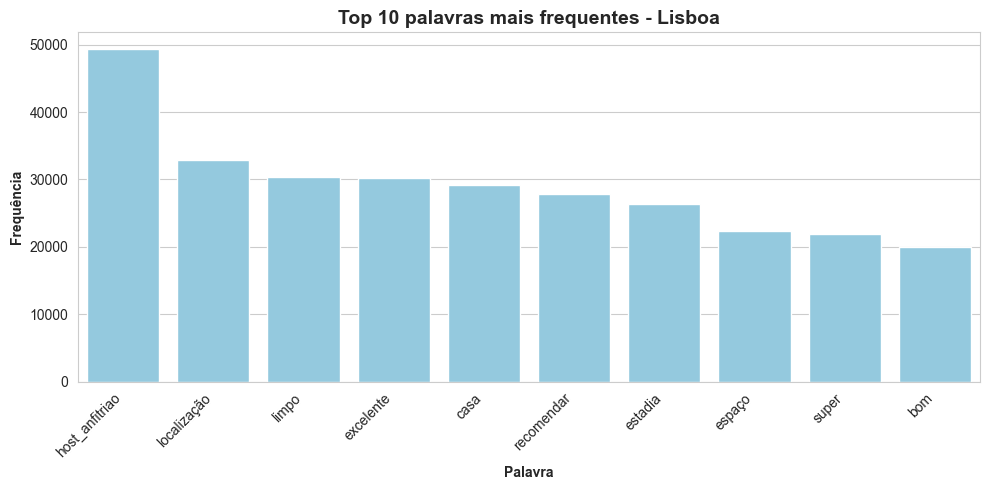

Gráfico de barras para as 10 palavras mais frequentes - Lisboa salvo como 'top10_freq_palavras_Lisboa.png'


<Figure size 640x480 with 0 Axes>

In [173]:
# ==========================================    
# Gráfico de barras para as 10 palavras mais frequentes - Lisboa
# ==========================================
sns.set_style("whitegrid")

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_Lisboa, x='Palavra', y='Frequência', color='skyblue')

plt.xlabel('Palavra', fontweight='bold')
plt.ylabel('Frequência', fontweight='bold')
plt.title('Top 10 palavras mais frequentes - Lisboa', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ==========================================
# Salva o gráfico de barras para as 10 palavras mais frequentes - Lisboa
# ==========================================
plt.savefig("top10_freq_palavras_Lisboa.png", dpi=300, bbox_inches="tight")
print("Gráfico de barras para as 10 palavras mais frequentes - Lisboa salvo como 'top10_freq_palavras_Lisboa.png'")

In [174]:
# ==========================================
# Remover várias colunas
# ==========================================
df_Lisboa_finalizar = df_Lisboa_Lematizar.drop(columns=['id', 'listing_id', 'reviewer_id', 'reviewer_name'])
df_Lisboa_finalizar.head()

,date,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado,texto_lematizado
0,2016-01-18,Adoramos o lugar. Muito bem localizado e prático. Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária.,Lisboa,pt,137,21,Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela Inês que nos prestou toda a assistência necessária,[Inês],Adoramos o lugar Muito bem localizado e prático Fomos muito bem recepcionados pela host_anfitriao que nos prestou toda a assistência necessária,adoramos o lugar muito bem localizado e prático fomos muito bem recepcionados pela host_anfitriao que nos prestou toda a assistência necessária,adorar localizar prático recepcionar host_anfitriao prestar assistência necessário
4,2017-11-27,Apartamento muito bom. Anfitrião atencioso e solícito. Não tenho qualquer reclamação. Só elogios.,Lisboa,pt,97,13,Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios,[],Apartamento muito bom Anfitrião atencioso e solícito Não tenho qualquer reclamação Só elogios,apartamento muito bom anfitrião atencioso e solícito não tenho qualquer reclamação só elogios,anfitrião atencioso solícito reclamação elogio
6,2019-12-15,"O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada. No entanto, tive sérios problemas com o proprietário : mudaram a data do meu check in no dia que eu cheguei - eu viajei com toda minha família e tenho um bebe com menos de 2 anos. Há quedas correntes de energia. E a proprietária me cobrou de algo absurdo: o vidro do box que protege a área de banho se trincou sozinho. Poderia ter causado um enorme acidente ao meu filho e demais membros da família. E a proprietária insiste em me cobrar o valor como se eu ou alguém tivéssemos feito algo. Um técnico foi ao local e confirmou que isso acontecia com o tempo, fiz até um video do vidro se despedaçando. Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de ""desculpas"",. veio uma cobrança. Muito absurdo.",Lisboa,pt,814,150,O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo,[],O apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada No entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos Há quedas correntes de energia E a proprietária me co ou de algo absurdo o vidro do box que protege a área de banho se trincou sozinho Poderia ter causado um enorme acidente ao meu filho e demais mem os da família E a proprietária insiste em me co ar o valor como se eu ou alguém tivéssemos feito algo Um técnico foi ao local e confirmou que isso acontecia com o tempo fiz até um video do vidro se despedaçando Quase nao dormi preocupada com meu filho e quando achei que merecia um pedido de desculpas veio uma co ança Muito absurdo,o apartamento é bem localizado e tem os utensílios para uma estadia mais prolongada no entanto tive sérios problemas com o proprietário mudaram a data do meu check in no dia que eu cheguei eu viajei com toda minha família e tenho um bebe com menos de anos há quedas correntes de energia e a proprietári

In [175]:
# ==========================================
# Exibe informações sobre o dataset de Lisboa após o pré-processamento.
# ==========================================
df_Lisboa_finalizar.info()

<class 'pandas.DataFrame'>
Index: 124783 entries, 0 to 1763340
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   date               124783 non-null  str   
 1   comments           124783 non-null  str   
 2   cidade             124783 non-null  str   
 3   lang               124783 non-null  str   
 4   char_count         124783 non-null  int64 
 5   word_count         124783 non-null  int64 
 6   texto_limpo        124783 non-null  str   
 7   nomes_proprios     124783 non-null  object
 8   texto_anonimizado  124783 non-null  str   
 9   texto_normalizado  124783 non-null  str   
 10  texto_lematizado   124783 non-null  str   
dtypes: int64(2), object(1), str(8)
memory usage: 11.4+ MB


-----
## **Informações básicas após o pré-processamento do Dataset de Lisboa:** 

- Total de Entradas: **124.783** 
- Total de Colunas: **11**
- Palavras Únicas Tokenizadas: **27355**
----------

In [176]:
# ==========================================
# Salvando o DataFrame pré-processado para Lisboa, e criando uma cópia de segurança
# ==========================================
df_Lisboa_finalizar.to_pickle("Reviews_Lisboa_Lematizado.pkl")

---------------------
##  **Fazer a junção dos datasets, Rio de Janeiro e Lisboa**
------------

###  Balanceamento dos datasets em (50% / 50%), com base na coluna **'cidade'**, sendo:

- **Rio de Janeiro:** 100.000 entradas
- **Lisboa:** 100.000 entradas

------------

In [22]:
# ==========================================
# Carregar os datasets processados
# ==========================================
df_RJ_concat = pd.read_pickle("Reviews_RJ_Lematizado.pkl")
df_Lisboa_concat = pd.read_pickle("Reviews_Lisboa_Lematizado.pkl")

# ==========================================
# Verificar o tamanho dos datasets
# ==========================================
print("RJ:", len(df_RJ_concat))
print("Lisboa:", len(df_Lisboa_concat))

# ==========================================
# Definir o tamanho de balanceamento
# ==========================================
n_amostra = 100000

# ==========================================
# Subamostragem sem duplicar texto
# ==========================================
df_RJ_bal = df_RJ_concat.sample(n=n_amostra, random_state=42)
df_Lisboa_bal = df_Lisboa_concat.sample(n=n_amostra, random_state=42)

# ==========================================
# Concatenar os dois conjuntos balanceados
# ==========================================
df_balancear = pd.concat([df_RJ_bal, df_Lisboa_bal], ignore_index=True)



RJ: 721089
Lisboa: 124783


In [23]:
# ==========================================
# Contar entradas por cidade após o balanceamento de dados
# ==========================================
df_balancear['cidade'].value_counts()

cidade
Rio de Janeiro    100000
Lisboa            100000
Name: count, dtype: int64

In [24]:
# ==========================================
# Conferir dataset
# ==========================================
df_balancear.head()

,date,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado,texto_lematizado
0,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,217,35,Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,[],Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,anfitrião maravilhoso casa charme macaquinho manhã varanda considerar móvel velho objeto pessoal acabar ficar cheiro forte guardar fechar
1,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,751,128,A estadia com o Renato foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o Renato passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o Renato para se hospedarem o Apartamento é fantastico,"[Renato, Renato, Renato]",A estadia com o host_anfitriao foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o host_anfitriao passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o host_anfitriao para se hospedarem o Apartamento é fantastico,a estadia com o host_anfitriao foi a melhor experiência no airbnb até hoje vou falar coisas que não poderia deixar passar a vista da cobertura é sensacional um ângulo de visão da bahia de guanabara pão de açucar aeroporto santos dumont e cristo redentor é sensacional a recepção no chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça a flexibilidade na reserva e as dicas do rj que o host_anfitriao passa são maravilhosas a localização do apartamento é fantástica pois fica pórximo

In [25]:
df_balancear.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   date               200000 non-null  str   
 1   comments           200000 non-null  str   
 2   cidade             200000 non-null  str   
 3   lang               200000 non-null  str   
 4   char_count         200000 non-null  int64 
 5   word_count         200000 non-null  int64 
 6   texto_limpo        200000 non-null  str   
 7   nomes_proprios     200000 non-null  object
 8   texto_anonimizado  200000 non-null  str   
 9   texto_normalizado  200000 non-null  str   
 10  texto_lematizado   200000 non-null  str   
dtypes: int64(2), object(1), str(8)
memory usage: 16.8+ MB


In [26]:
df_balancear_lema = df_balancear.copy()

In [27]:
# ==========================================
# Tokenização linha a linhada coluna 'texto_processado', para contar as 10 palavras mais frequentes
# ==========================================
palavras_bal = (word.lower()
               for review in df_balancear_lema['texto_lematizado'].astype(str)
               for word in review.split())

# ==========================================
# Contagem de palavras usando Counter
# ==========================================
contagem_bal = Counter(palavras_bal)

# ==========================================
# Número total de palavras únicas e as 10 mais frequentes
# ==========================================
num_palavras_unicas_bal = len(contagem_bal)
print("Reviews da junção das cidades de Lisboa e Rio de Janeiro")
print("Número total de palavras únicas:", num_palavras_unicas_bal)

# ==========================================
# Criando um DataFrame para exibir as palavras e suas frequências
# ==========================================
df_balancear_lema = pd.DataFrame(
    contagem_bal.most_common(),
    columns=['Palavra', 'Frequência']
)

top10_bal = df_balancear_lema.head(10).copy()
print("\nTop 10 palavras mais frequentes:")
top10_bal

Reviews da junção das cidades de Lisboa e Rio de Janeiro
Número total de palavras únicas: 34431

Top 10 palavras mais frequentes:


,Palavra,Frequência
0,host_anfitriao,81848
1,localização,60174
2,super,49387
3,excelente,49171
4,limpo,47388
5,estadia,44097
6,recomendar,42891
7,ótimo,39452
8,voltar,36308
9,casa,35400


---------------------
##  **Após o balanceamento dos datasets, com base na coluna **'cidade'**, resultou em:**

- Total de linhas: **200.000**
- Total de colunas: **11**
- Total de tokens: **34.431**

------------

In [3]:
# ==========================================
# Salvar o dataset balanceado de Lisboa e Rio de Janeiro, para uso posterior
# ==========================================
df_balancear.to_pickle("Reviews_Lisboa_RJ_200k.pkl")
print("Dataset balanceado salvo com sucesso!")

NameError: name 'df_balancear' is not defined

-----------
# Verificar Dataset
---------

In [4]:
verificar = pd.read_pickle("Reviews_Lisboa_RJ_200k.pkl")
verificar.head()

,date,comments,cidade,lang,char_count,word_count,texto_limpo,nomes_proprios,texto_anonimizado,texto_normalizado,texto_lematizado
0,2025-06-23,"Os anfitriões são maravilhosos, a casa é um charme com macaquinhos vindo toda manhã na varanda, porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada",Rio de Janeiro,pt,217,35,Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,[],Os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,os anfitriões são maravilhosos a casa é um charme com macaquinhos vindo toda manhã na varanda porém considerando ter muitos móveis velhos e objetos pessoais acaba ficando com cheiro forte de coisa guardada e fechada,anfitrião maravilhoso casa charme macaquinho manhã varanda considerar móvel velho objeto pessoal acabar ficar cheiro forte guardar fechar
1,2022-05-02,"A estadia com o Renato foi a melhor experiência no Airbnb até hoje .<br/>Vou falar 4 coisas que não poderia deixar passar.<br/>01- A vista da cobertura é sensacional , um ângulo de visão da Bahia de Guanabara , Pão de Açucar , Aeroporto Santos Dumont e Cristo Redentor é sensacional.<br/>02- A recepção no Chek-in foi indescritível , fomos recebidos com algumas surpresas que me deixaram de queixo caído , uma delas é de uma simpatia sem igual, mas não posso contar a vocês porque perderia a graça.<br/>03- A flexibilidade na reserva e as dicas do RJ que o Renato passa , são maravilhosas.<br/>04- A localização do apartamento é fantástica pois fica pórximo a tudo.<br/>Enfim , Super indico o Renato para se hospedarem , o Apartamento é fantastico !!!",Rio de Janeiro,pt,751,128,A estadia com o Renato foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o Renato passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o Renato para se hospedarem o Apartamento é fantastico,"[Renato, Renato, Renato]",A estadia com o host_anfitriao foi a melhor experiência no Airbnb até hoje Vou falar coisas que não poderia deixar passar A vista da cobertura é sensacional um ângulo de visão da Bahia de Guanabara Pão de Açucar Aeroporto Santos Dumont e Cristo Redentor é sensacional A recepção no Chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça A flexibilidade na reserva e as dicas do RJ que o host_anfitriao passa são maravilhosas A localização do apartamento é fantástica pois fica pórximo a tudo Enfim Super indico o host_anfitriao para se hospedarem o Apartamento é fantastico,a estadia com o host_anfitriao foi a melhor experiência no airbnb até hoje vou falar coisas que não poderia deixar passar a vista da cobertura é sensacional um ângulo de visão da bahia de guanabara pão de açucar aeroporto santos dumont e cristo redentor é sensacional a recepção no chek in foi indescritível fomos recebidos com algumas surpresas que me deixaram de queixo caído uma delas é de uma simpatia sem igual mas não posso contar a vocês porque perderia a graça a flexibilidade na reserva e as dicas do rj que o host_anfitriao passa são maravilhosas a localização do apartamento é fantástica pois fica pórximo

In [6]:
verificar["num_palavras"] = verificar["texto_limpo"].fillna("").astype(str).str.split().str.len()

media_palavras_por_cidade = (
    verificar.groupby("cidade", as_index=False)["num_palavras"]
    .mean()
    .rename(columns={"num_palavras": "media_palavras_por_review"})
    .sort_values("media_palavras_por_review", ascending=False)
)

display(media_palavras_por_cidade)

,cidade,media_palavras_por_review
1,Rio de Janeiro,34.05179
0,Lisboa,33.38619


In [7]:
import pandas as pd

# 1) Contar tokens em cada review
verificar["num_tokens"] = verificar["texto_lematizado"].fillna("").str.split().str.len()

# 2) Calcular a média de tokens por cidade
media_tokens_por_cidade = (
    verificar.groupby("cidade", as_index=False)["num_tokens"]
    .mean()
    .rename(columns={"num_tokens": "media_tokens"})
)

display(media_tokens_por_cidade)

,cidade,media_tokens
0,Lisboa,15.52690
1,Rio de Janeiro,16.10219
